In [ ]:

#def get_return_portfolie(df, names, blanka = False, weighting = "equal", lend_possible = True, combine_str="_none"):

#  cols = [name + "_signal" + combine_str for name in names]
#  for name in names:
#    df[name + "_change" + combine_str] = df[name]/df[name].shift(1)

#  if blanka:
#    df["stocks_active" + combine_str] = (df[cols] == -1 or df[cols]==1).sum(axis=1).shift(1)
 # else:
#    df["stocks_active" + combine_str] = (df[cols] == 1).sum(axis=1).shift(1)

#  return_no_trade = 1.03 ** (1/252) - 1 if lend_possible else 0.

#  df["total_return_per_day" + combine_str] = np.nan

#  for name in names:
#    df[name + "_return" + combine_str] = np.nan
#
#  for i in range(1, len(df)):
#
#    for name in names:
#      if blanka:
##        df.loc[i, name + "_return" + combine_str] = (df.loc[i, name + "_change" + combine_str] - 1) * (int(df.loc[i - 1, name + "_signal" + combine_str] == 1) +
#                                                    (1 - df.loc[i, name + "_change" + combine_str]) * int(df.loc[i - 1][name + "_signal" + combine_str] == -1))
#      else:
#        df.loc[i, name + "_return" + combine_str] = (df.loc[i, name + "_change" + combine_str] - 1) * int(df.loc[i - 1, name + "_signal" + combine_str] == 1)

#    if weighting == "equal":
#
#      if df.loc[i, "stocks_active" + combine_str] == 0 or np.isnan(df.loc[i, "stocks_active" + combine_str]):
#        df.loc[i, "total_return_per_day" + combine_str] = return_no_trade + 1
#
#      else:
#        stocks_return_names = [name + "_return" + combine_str for name in names]
#        returns =  [df.loc[i, stocks_return_name] / df.loc[i, "stocks_active" + combine_str] for stocks_return_name in stocks_return_names]
#        df.loc[i, "total_return_per_day" + combine_str] = np.array(returns).sum() + 1
#
#    elif weighting == "active":
#      return_weighted = 0
#      sum_weighted = 0
#      for name in names:
#        if blanka or df.loc[i - 1, name + "_signal" + combine_str] == 1:
#          return_weighted += df.loc[i, name + "_return" + combine_str] * df.loc[i, name].shift(1)
#          sum_weighted += df.loc[i, name].shift(1)
#
#      if sum_weighted == 0:
#        df.loc[i, "total_return_per_day" + combine_str] = return_no_trade + 1
#      else:
#        df.loc[i, "total_return_per_day" + combine_str] = return_weighted / sum_weighted + 1
#  df.drop(columns=[name + "_return" + combine_str for name in names])
#  df.drop(columns=[name + "_change" + combine_str for name in names])
#  df.drop(columns=[name + "_signal" + combine_str for name in names])
#  df.drop(columns=["stocks_active" + combine_str for name in names])
#
#  return df

#def get_return_portfolie_buy_and_hold(df, names, blanka=False, weighting="equal", lend_possible=True):
#    combine_str = "_buy_and_hold"
#
#    # compute individual returns first
#    for name in names:
#        df[name + "_return" + combine_str] = df[name] / df[name].shift(1)
#
#    return_no_trade = 1.03 ** (1/252) if lend_possible else 1.0
#
#    df["total_return_per_day" + combine_str] = np.nan
#
#    stocks_active = len(names)
#
#    for i in range(1, len(df)):
#        stocks_active = df.loc[i, names].notna().sum()
#
#        if weighting == "equal":
#            returns = [df.loc[i, name + "_return" + combine_str] / stocks_active for name in names]
#            df.loc[i, "total_return_per_day" + combine_str] = np.nansum(returns)
#
#        elif weighting == "active":
#            return_weighted = 0.0
#            sum_weighted = 0.0
#
#            for name in names:
#                w = df.loc[i-1, name]
#                r = df.loc[i, name + "_return" + combine_str]
#
#                return_weighted += r * w
#                sum_weighted += w
#
#            if sum_weighted == 0:
#                df.loc[i, "total_return_per_day" + combine_str] = return_no_trade
#            else:
#                df.loc[i, "total_return_per_day" + combine_str] = return_weighted / sum_weighted
#    df.drop(columns=[name + "_return" + combine_str for name in names])
#    return df

#def get_sharpe_ratio(df, names, intervall=21, short_window=25, long_window=100, combine_str = None, weighting = "equal", renta = 1.03):
#  if combine_str == None:
#    combine_str = "_" + str(short_window) + "_" + str(long_window) if combine_str is None else combine_str
#    lower_limit = long_window
#
#  df = df.copy()
#
#  nan_indicies = df[names[0]][df[names[0]].isna()].index
#  upper_limit = min(nan_indicies[nan_indicies > 5000])
#  if combine_str != None:
#    lower_limit = max(nan_indicies[nan_indicies < 5000])
#  print(lower_limit, upper_limit)
#
#  #print(df.iloc[lower_limit:upper_limit]["total_return_per_day" + combine_str])
#  returns = (df.iloc[lower_limit:upper_limit]["total_return_per_day" + combine_str].rolling(window=intervall)).apply(np.prod, raw=True).dropna()#.iloc[::intervall]
#  print(np.mean(returns), np.std(returns))
#  cost_rent = 1.03 ** (intervall/252)
#  return np.mean(returns - cost_rent) / np.std(returns - cost_rent)

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from math import isnan
def moving_avarage_cross_over(data_frame, name, short_window=25, long_window=100):
    data_frame = data_frame.copy()
    long_window_text = "_" + str(long_window)
    short_window_text = "_" + str(short_window)
    combine_str = short_window_text + long_window_text

    data_frame[name + '_MA_short' + combine_str] = data_frame[name].rolling(window=short_window).mean()
    data_frame[name + '_MA_long' + combine_str] = data_frame[name].rolling(window=long_window).mean()

    data_frame[name + '_signal' + combine_str] = 0

    valid = data_frame[name + '_MA_long' + combine_str].notna()

    data_frame.loc[valid & (data_frame[name+'_MA_short' + combine_str] >= data_frame[name+'_MA_long' + combine_str]), name + '_signal' + combine_str] = 1
    data_frame.loc[valid & (data_frame[name+'_MA_short' + combine_str] < data_frame[name+'_MA_long' + combine_str]), name + '_signal' + combine_str] = -1
    data_frame[name+'_position' + combine_str] = data_frame[name+'_signal' + combine_str].diff()
    data_frame = data_frame.drop(columns=[name + '_MA_short' + combine_str,  name + '_MA_long' + combine_str])
    return data_frame

def channal_breakout(data_frame, name, c = 0.05, d = 3, k = 5, x = 0.03, j = 20, combine_str = "_none"):
    data_frame = data_frame.copy()

    high = data_frame[name].shift(d).rolling(window= j).max()
    low = data_frame[name].shift(d).rolling(window= j).min()

    channal_exist = (high <= low * (1 + c))
    upper = high * (1 + x)
    lower = low * (1 - x)

    lag_min = data_frame[name].rolling(window = d).min()
    lag_max = data_frame[name].rolling(window = d).max()

    _long = (lag_min > upper) & channal_exist
    _short = (lag_max < lower) & channal_exist

    nan_Frame = data_frame[name].isna().fillna(False)

    bad = nan_Frame.rolling(window = d + j, min_periods=1).max()
    _valid_breakouts = bad.eq(0).fillna(False)

    _signal = np.zeros(len(data_frame[name]))
    nan_Frame = nan_Frame.to_numpy()
    _valid_breakouts = _valid_breakouts.to_numpy()
    _long = _long.to_numpy()
    _short = _short.to_numpy()

    for i in range(d + j, len(data_frame[name])):
      if not (nan_Frame[i] == True):
        _signal[i] = -1
    ld = len(data_frame[name])

    for i in range(d + j, len(data_frame[name]) - 1):
      if _valid_breakouts[i]:
        if _long[i]:
          _signal[i: min(i + k, ld)] = 1
          if i + k < ld:
            _signal[i + k] = -1
        elif _short[i]:
          _signal[i: min(i + k, ld)] = -1
          #if i + k < ld:
          #  _signal[i + k] = 1

    for i in range(d + j, len(data_frame[name]) - 1):
      if nan_Frame[i]:
        _signal[i] = 0
      elif nan_Frame[i + 1]:
        _signal[i] = -1

    _signal[-1] = _signal[-2]
    #for i in range(_signal.shape[0]):
    #  print(i, _signal[i])

    _signal = _signal.astype(int)

    data_frame[name + '_signal' + combine_str] = _signal
    vc = data_frame[name + '_signal' + combine_str].value_counts()

    print(vc.get(-1, 0), vc.get(1, 0))

    #data_frame = data_frame.drop(columns=[name + '_channal_short' + combine_str,  name + '_channal_long' + combine_str, name + '_valid_break_outs' + combine_str])
    return data_frame,  vc.get(1, 0)

def buy_and_hold_signal(data_frame, names, combine_str = "buy_and_hold"):
    data_frame = data_frame.copy()
    for name in names:
      _signal = np.zeros(len(data_frame[name]))
      _price = data_frame[name].to_numpy()

      _signal[0] = -1
      #data_frame[name + '_signal' + combine_str] = _signal
      for i in range(1, len(data_frame) - 1):
        if np.isnan(_price[i]):
          _signal[i] = 0
        elif np.isnan(_price[i + 1]):
          _signal[i] = -1
        elif np.isnan(_price[i - 1]):
          _signal[i] = -1
        else:
          _signal[i] = 1
      _signal[-1] = _signal[-2]
      data_frame[name + '_signal' + combine_str] = _signal

    return data_frame

def buy_dip(data_frame, names, d, k, max_k, combine_str = "dipen", shift_v = 0):
    data_frame = data_frame.copy()
    for name in  names:
#      _valid = np.zeros(len(data_frame[name]), dtype=bool)
      _valid = data_frame[name].shift(shift_v).isna().rolling(window=d).sum().to_numpy() == 0
      _rolling = data_frame[name].shift(shift_v).rolling(window=d)
      _price = data_frame[name].to_numpy()
      _price1 = data_frame[name].shift(shift_v).to_numpy()
      for i in range(0, len(data_frame) - 1):
        if np.isnan(_price[i]) or np.isnan(_price[i+1]):
          _valid[i] = False

      _avg =  _rolling.mean().to_numpy()
      _std = _rolling.std().to_numpy()
      _signal = np.where((_price1 < _avg - k * _std) & _valid, 1, -1)
#      _signal = np.array([0] + _signal[:-1].tolist())
      sh = 0
      print(np.sum(_signal == 1))
      buy_now = False
      day_since_buy = 0
      for i in range(0, len(data_frame) - 1):
        if _signal[i] == 1:
          buy_now = True
          day_since_buy = 0
        else:
          if _valid[i] == False or _valid[i] == False:
            _signal[i] = 0
            buy_now = False
            day_since_buy = 0
          elif _price1[i] >= _avg[i]:
              _signal[i] = -1
              buy_now = False
              day_since_buy = 0
          elif buy_now:
            day_since_buy += 1
            if day_since_buy > max_k:
              _signal[i] = -1
              buy_now = False
              day_since_buy = 0
            else:
              _signal[i] = 1
          else:
            _signal[i] = -1

      _signal[-1] = _signal[-2]
      print(np.sum(_signal == 1))
      data_frame[name + '_signal' + combine_str] = _signal
    return data_frame

def remove_1000(data_frame, name):
    data_frame = data_frame.copy()
    mask = data_frame[name] == 1000
    idx = np.where(mask)[0]  # positional indices

    # avoid boundary issues
    valid = (idx > 0) & (idx < len(data_frame) - 1)
    idx = idx[valid]

    before = data_frame[name].iloc[idx - 1].to_numpy()
    after  = data_frame[name].iloc[idx + 1].to_numpy()
    print(before, after)
    data_frame.iloc[idx, data_frame.columns.get_loc(name)] = (before + before) / 2

    return data_frame

def remove_last_days(data_frame):
    data_frame = data_frame.copy()
    nan_indicies = data_frame.iloc[5000:]["gurkor"].isna().to_numpy().nonzero()[0]
    nan_first = nan_indicies.min() + 5000
    data_frame = data_frame.iloc[:nan_first]
    return data_frame

def training_test_split(data_frame, part_slit=0.8):
    nan_max = len(data_frame)
    nan_min = 0

    split_idx = int(nan_min + (nan_max - nan_min) * part_slit)
    data_frame = data_frame.copy()
    train_df = data_frame.iloc[:split_idx].copy()
    test_df = data_frame.iloc[split_idx:].copy()

    return train_df, test_df

In [4]:
def get_log_returns(df, names):
  for name in names:
    df[name + "_daily-log-return"] = np.log(df[name]/df[name].shift(1))
  return df

def stocks_positions(df, names, combine_str):
  for name in names:
    str_signal = name + "_signal" + combine_str

    str_pos_buy = name + "buy" + combine_str
    str_pos_sell = name + "sell" + combine_str
    str_unvalid_next = name + "unvalid" + combine_str

    signal = df[str_signal]
    pos = signal - signal.shift(1)

    df[str_pos_buy] = np.where(pos == 2, True, False)
    df[str_pos_sell] = np.where(pos == -2, True, False)
    df[str_unvalid_next] = np.where((pos== 1) | (pos == -1), True, False)

  return df

def several_stock_trade(df, names, combine_str, relative_money = 100., rebalancing_interval = None, blanka = False, interest = 1.03, replacing_weight = 1.5, maximum_in_one_stock = 0.5):
  df = df.copy()
  if rebalancing_interval == None:
    rebalancing_interval = len(df)

  interest_per_day = (1.03)**(1/252)

  stocks = len(names)

  prices = df[names].to_numpy()

  buy_days =  df[[name + "buy" + combine_str for name in names]].to_numpy(dtype = np.bool)
  sell_days = df[[name + "sell" + combine_str for name in names]].to_numpy(dtype = np.bool)

  if blanka:
    buy_short = df[[name + "buy_short" + combine_str for name in names]].to_numpy(dtype = np.bool)
    sell_short = df[[name + "sell_short" + combine_str for name in names]].to_numpy(dtype = np.bool)

  unvalid_days = df[[name + "unvalid" + combine_str for name in names]].to_numpy(dtype = np.bool)

  value_now = np.zeros(unvalid_days.shape[0])

  stocks_hold = np.zeros((unvalid_days.shape[0], 1 + stocks))

  stocks_hold[0, stocks] = relative_money

  stocks_have_now_as_bool = buy_days[0]
  n_stocks_holding = np.sum(stocks_have_now_as_bool.astype(int))

  if n_stocks_holding > 0:
    for j in range(stocks):
      if buy_days[0, j]:
        stocks_hold[1, j] = relative_money/ n_stocks_holding
    stocks_hold[1, stocks] = 0.
  else:
    stocks_hold[1, stocks] = relative_money

  value_now[0] = relative_money

  for i in range(1, len(df) - 1):

    stocks_bought = (buy_days[i] & (~unvalid_days[i + 1])) & (~stocks_have_now_as_bool)
    stocks_sold = (sell_days[i] | unvalid_days[i + 1]) & stocks_have_now_as_bool
    stocks_unchanged = (~stocks_bought) & (~stocks_sold) & stocks_have_now_as_bool
    stocks_have_now_as_bool = stocks_bought | stocks_unchanged

    stocks_bought_b = stocks_bought.nonzero()[0]
    stocks_sold_b = stocks_sold.nonzero()[0]
    stocks_unchanged_b = stocks_unchanged.nonzero()[0]


    n_bought_stocks = len(stocks_bought_b)
    n_sold_stocks = len(stocks_sold_b)
    n_stocks_unchanged = len(stocks_unchanged_b)

    n_stocks_holding = n_stocks_unchanged + n_bought_stocks

    value_now[i] = np.sum(stocks_hold[i, :])
    #print(value_now[i], stocks_bought_b, stocks_sold_b, stocks_unchanged_b, stocks_hold[i])


    value_sold = 0.
    value_bought = 0.

    if n_stocks_holding > 0:
      # if money exist and we hold stocks sell all money
      if stocks_hold[i, stocks] > 0:
        value_sold += stocks_hold[i, stocks]
        stocks_hold[i + 1, stocks] = 0.

      # buy stocks for procentual part
      if n_bought_stocks > 0:
        for j in stocks_bought_b:
            stocks_hold[i + 1, j] = value_now[i] / n_stocks_holding
            value_bought += stocks_hold[i + 1, j]

      #sell socks if signal or to much value of portfolie
      if n_sold_stocks > 0:
        for j in stocks_sold_b:
            value_sold += stocks_hold[i, j]
            stocks_hold[i + 1, j] = 0.

      maximum_value_hold = replacing_weight * value_now[i] / n_stocks_holding

      if n_stocks_unchanged > 0:
        for j in stocks_unchanged_b:
          if stocks_hold[i, j] > maximum_value_hold:
            value_sold += stocks_hold[i, j] - maximum_value_hold
            stocks_hold[i + 1, j] = maximum_value_hold
          else:
            stocks_hold[i + 1, j] = stocks_hold[i, j]

      # the left money add equaly or sell per procent
      rest_money = value_sold - value_bought

      if rest_money > 0:
        for j in stocks_unchanged_b:
          stocks_hold[i + 1, j] += rest_money / n_stocks_unchanged
      else:
        capital = 0.
        for j in stocks_unchanged_b:
          capital += stocks_hold[i, j]

        for j in stocks_unchanged_b:
          stocks_hold[i + 1, j] += rest_money * stocks_hold[i, j] / capital

      # rebalancing portfolie
      if i % rebalancing_interval == 0:
        for j in range(stocks):
          if stocks_hold[i + 1, j] > 0:
            stocks_hold[i + 1, j] = value_now[i] / n_stocks_holding
          elif stocks_hold[i + 1, j] == 0:
            stocks_hold[i + 1, j] = 0.
          else:
            print("error sss")

        if n_stocks_holding > 0:
          stocks_hold[i + 1, stocks] = 0.
        else:
          stocks_hold[i + 1, stocks] = value_now[i]
    else:
      # have no stocks
      for j in range(stocks):
        stocks_hold[i + 1, j] = 0.
      stocks_hold[i + 1, stocks] = value_now[i]

    # if one stock is overrepresented
    stocks_avalible = np.where(stocks_hold[i + 1, :] > 0, 1, 0).nonzero()[0]
    money_left = 0
    for j in stocks_avalible:
      if stocks_hold[i + 1, j] > maximum_in_one_stock * value_now[i]:
        money_left += stocks_hold[i + 1, j] - maximum_in_one_stock * value_now[i]
        stocks_hold[i + 1, j] = maximum_in_one_stock * value_now[i]

    if money_left > 0:
        stocks_hold[i + 1, stocks] += money_left

    # add interests and returns
    for j in range(stocks):
      if stocks_hold[i + 1, j] < 0:
        print("error")
        stocks_hold[i + 1, j] = 0.
      if (np.isnan(prices[i + 1, j])) or (np.isnan(prices[i, j])):
        stocks_hold[i + 1, stocks] += stocks_hold[i + 1, j]
        stocks_hold[i + 1, j] = 0.
      else:
        stocks_hold[i + 1, j] *= prices[i + 1, j] / prices[i, j]
    stocks_hold[i + 1, stocks] *= interest_per_day

  value_now[-1] = np.sum(stocks_hold[-1, :])

  for j, name in enumerate(names):
    df[name + "_portfolie_stock" + combine_str] = stocks_hold[:, j]

  df["portfolie_money" + combine_str] = stocks_hold[:, stocks]
  df["portfolie_value" + combine_str] = value_now

  return df

In [81]:
def get_sharpe_ratio(df, intervall=252, combine_str = None, weighting = "equal", renta = 1.03):
  df = df.copy()

  values = df["portfolie_value" + combine_str]
  cost_rent = 1.03 ** (intervall/252) - 1
  returns = (values/values.shift(intervall)).dropna() - 1 - cost_rent

  print("\t\t\t", np.mean(returns), np.std(returns))

  return np.mean(returns) / np.std(returns)

def get_sharpe_ratio_v2(df, intervall=252, combine_str = None, weighting = "equal", renta = 1.03):
  df = df.copy()

  values = df["portfolie_value" + combine_str]
  cost_rent = 1.03 ** (intervall/252) - 1
  returns = (values/values.shift(intervall)).dropna() - 1 - cost_rent

  print("\t\t\t", np.mean(returns), np.std(returns))

  return np.mean(returns) / np.std(returns), np.mean(returns), np.std(returns)

def get_sharpe_ratio_one_stock(df, name, intervall=252, combine_str = None, weighting = "equal", renta = 1.03):
  df = df.copy()
  unvalid = df[name + "unvalid" + combine_str]
  ok = ~(unvalid | unvalid.shift(intervall))

  values = df[name + "_portfolie_ind_value" + combine_str]

  cost_rent = 1.03 ** (intervall/252) - 1

  returns = (values[ok]/values[ok].shift(intervall)).dropna() - 1 - cost_rent

  print("\t\t\t", np.mean(returns), np.std(returns))#, returns)

  return np.mean(returns) / np.std(returns)

In [2]:
def one_stock_trade(df, name, combine_str, relative_money = 100., rebalancing_interval = None, balnka = False, interest = 1.03):
  df = df.copy()
  if rebalancing_interval == None:
    rebalancing_interval = len(df)

  interest_per_day = (1.03)**(1/252)

  prices = df[name].to_numpy()

  buy_days =  df[name + "buy" + combine_str].to_numpy(dtype = np.bool)
  sell_days = df[name + "sell" + combine_str].to_numpy(dtype = np.bool)

  unvalid_days = df[name + "unvalid" + combine_str].to_numpy(dtype = np.bool)

  value_now = np.zeros(unvalid_days.shape[0])

  stocks_hold = np.zeros((unvalid_days.shape[0], 1 + 1))

  stocks_hold[0, 1] = relative_money

  if buy_days[0]:
    stocks_hold[1, 0] = relative_money
    stocks_hold[1, 1] = 0
  else:
    stocks_hold[1, 1] = relative_money

  value_now[0] = relative_money

  for i in range(1, len(df) - 1):
    stocks_bought = buy_days[i] and (not unvalid_days[i + 1])
    stocks_sold = (sell_days[i] or unvalid_days[i + 1])

    value_now[i] = stocks_hold[i, 0] + stocks_hold[i, 1]
    #print(stocks_bought, stocks_sold, stocks_hold[i])

    if stocks_sold:
      stocks_hold[i + 1, 1] = value_now[i]
      stocks_hold[i + 1, 0] = 0
    if stocks_bought:
      stocks_hold[i + 1, 0] = value_now[i]
      stocks_hold[i + 1, 1] = 0
    else:
      stocks_hold[i + 1, 0] = stocks_hold[i, 0]
      stocks_hold[i + 1, 1] = stocks_hold[i, 1]

    # add interests and returns
    if stocks_hold[i + 1, 0] < 0:
        print("error")
        stocks_hold[i + 1, 0] = 0
    if (np.isnan(prices[i + 1])) or (np.isnan(prices[i])):
      stocks_hold[i + 1, 1] = value_now[i]
      stocks_hold[i + 1, 0] = 0
    else:
      stocks_hold[i + 1, 0] *= prices[i + 1] / prices[i]

    stocks_hold[i + 1, 1] *= interest_per_day

  value_now[-1] = stocks_hold[-1, 0] + stocks_hold[-1, 1]

  df[name + "_portfolie_ind_stock" + combine_str] = stocks_hold[:, 0]
  df[name + "_portfolie_ind_money" + combine_str] = stocks_hold[:, 1]
  df[name + "_portfolie_ind_value" + combine_str] = value_now

  return df

In [89]:
def plot_time_series(days, data, sharp_ratio = 0, average_return = 0, avg_std=0, title_s="s"):
  fig = plt.figure(figsize=(14,5))
  gs = fig.add_gridspec(1,1,height_ratios = [3], hspace = 0.4)

  fig.suptitle(title_s, fontsize=18)
  sharp_text = (f"Trading on 1052 days after training on the first 4204 days.\n Allowing shorting = False. Sharp-ratio (annualized): {sharp_ratio:.4f}.\n Average return (annulized): {0.03+average_return:.2%}. Average standard deviation (annulized): {avg_std:.2%}.")

  fig.text(0.5, 0.9, sharp_text, fontsize = 12, ha = "center", va = "top", multialignment = "center", bbox = dict(facecolor = "lightblue",edgecolor = "black", boxstyle = "round,pad=0.5"))

  ax = fig.add_subplot(gs[0])
  ax.set_position([0.06, 0.08, 0.91, 0.55])
  ax.plot(days, data, label = "Strategy portfolio value", linewidth = 2)
  risk_free = data[0] * np.exp(0.03/252 * (days-days[0]))
  ax.plot(days, risk_free, label = "Risk - free asset", linestyle = "--", linewidth = 2)
  ax.set_title("Portfolio value against risk-free asset")
  ax.legend()
  ax.grid(True)
  ax.set_xlabel("Days")
  ax.set_ylabel("Value")
  plt.show()

# all

In [7]:
finance_data = pd.read_csv('spiff_data-2.csv')
finance_names = finance_data.keys()[2:].to_list()
print(finance_data)

      Unnamed: 0   day    gurkor   guitars  slingshots     stocks     sugar  \
0              0     1  6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2  6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3  6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4  6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5  6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...       ...       ...         ...        ...       ...   
5451        5451  5452       NaN       NaN         NaN        NaN       NaN   
5452        5452  5453       NaN       NaN         NaN        NaN       NaN   
5453        5453  5454       NaN       NaN         NaN        NaN       NaN   
5454        5454  5455       NaN       NaN         NaN        NaN       NaN   
5455        5455  5456       NaN       NaN         NaN        NaN       NaN   

         water  tranquillity  
0     3.896149      

In [8]:
finance_data = remove_last_days(finance_data)

for name in finance_names:
  finance_data = remove_1000(finance_data, name)

print(finance_data)

[ 6.31581555  6.825179    9.27880519  9.05006504 11.37014512] [ 6.26452498  6.85266821  9.181506    9.04200502 11.46444389]
[2.83043642 5.74900107 4.85888389 6.81445677 5.05114593] [2.85406559 5.41987344 4.85304529 6.82222064 4.90162681]
[2.05786636 3.39560267 3.81753475 4.92829802 3.06994825] [2.07016982 3.44239554 3.88330984 4.92515297 3.00913931]
[9.10307757 8.68991977 6.27277201 5.13249983 4.63075894] [8.83745388 8.8367195  6.20489274 5.0972318  4.54038977]
[3.57234686 3.39488235 2.07917243 3.30055146 1.760932  ] [3.64148906 3.23149229 2.07161867 3.30825403 1.72400296]
[3.97410653 4.69767736 5.89565424 6.21961548 6.6929798 ] [3.99621039 4.704141   5.88280296 6.20774392 6.7114342 ]
[ 7.46344565 10.34647171 10.41322314 18.65861411 10.20343293] [ 7.40623013 10.29561348 10.40686586 19.16719644  9.89192626]
      Unnamed: 0   day     gurkor   guitars  slingshots     stocks     sugar  \
0              0     1   6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2

In [9]:
training_data, test_data = training_test_split(finance_data)

In [10]:
print(training_data, test_data)

      Unnamed: 0   day     gurkor   guitars  slingshots     stocks     sugar  \
0              0     1   6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2   6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3   6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4   6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5   6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...        ...       ...         ...        ...       ...   
4199        4199  4200  11.192388  4.746119    2.948472   4.640011  1.771908   
4200        4200  4201  11.206871  4.892829    3.055226   4.570905  1.771908   
4201        4201  4202  11.211216  4.853407    3.052194   4.641266  1.771908   
4202        4202  4203  11.225699  4.913787    3.063112   4.647142  1.771908   
4203        4203  4204  11.147491  4.805002    2.995784   4.586083  1.836662   

         water  tranquillity  
0     3.

Moving Avarge

In [ ]:
short_windows = [4, 9, 14, 25, 35, 50]
long_windows = [15, 25, 50, 100, 150, 200]
periods = []

for short_window in short_windows:
  for long_window in long_windows:
    if short_window * 1.5 < long_window:
      periods.append([short_window, long_window])

In [ ]:
finance_data_moving_avarge_train = training_data.copy()
finance_data_moving_avarge_test = test_data.copy()

In [ ]:
sharp_ratios_moving_avarge = {}

for short_window, long_window in periods:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_moving_avarge_train_l = finance_data_moving_avarge_train.copy()
  for i, name in enumerate(finance_names):
    finance_data_moving_avarge_train_l = moving_avarage_cross_over(finance_data_moving_avarge_train_l, name, short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge[combine_str]}")
#  for name in finance_names:
#    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train, name, 252, combine_str = combine_str)}")


short window 4, long window 15 checked
			 -0.008105964010485214 0.08934227783956421
	 sharp ratio portfolie: -0.09072931882307102
short window 4, long window 25 checked
			 0.0010908524873230682 0.08260295464008667
	 sharp ratio portfolie: 0.013205974193974953
short window 4, long window 50 checked
			 0.030058897123313874 0.08001165902810743
	 sharp ratio portfolie: 0.3756814630322118
short window 4, long window 100 checked
			 0.01959328206063385 0.09887391570162485
	 sharp ratio portfolie: 0.19816431787491007
short window 4, long window 150 checked
			 0.022941223696234664 0.10777749595734776
	 sharp ratio portfolie: 0.21285727129264076
short window 4, long window 200 checked
			 0.024626108042040858 0.1083980393902269
	 sharp ratio portfolie: 0.22718222746989217
short window 9, long window 15 checked
			 0.015788220651126384 0.08552966050100558
	 sharp ratio portfolie: 0.18459351479526523
short window 9, long window 25 checked
			 0.012815213742454958 0.08473150401591005
	 sharp r

In [ ]:
sorted_d = dict(sorted(sharp_ratios_moving_avarge.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)


_14_50 0.4775674800457968
_9_100 0.42075658093811197
_9_50 0.4147494091563059
_14_200 0.38580598149025974
_14_150 0.37642344608914124
_4_50 0.3756814630322118
_25_100 0.3667369086002207
_9_150 0.36465997126314587
_25_200 0.35416550209312747
_14_100 0.34252409692324426
_25_50 0.3280099527527087
_25_150 0.32387314390655947
_9_200 0.29540781752258355
_14_25 0.2856413857114374
_35_150 0.2805964372615655
_50_150 0.27150513907797214
_50_200 0.27099788140746517
_35_200 0.23710904405813424
_4_200 0.22718222746989217
_35_100 0.22516819043752923
_4_150 0.21285727129264076
_4_100 0.19816431787491007
_9_15 0.18459351479526523
_9_25 0.151244969522182
_50_100 0.13832638073713746
_4_25 0.013205974193974953
_4_15 -0.09072931882307102


In [ ]:
short_windows_1 = [10, 15, 20, 25, 30]
long_windows_1 = [35, 40, 50, 60, 70, 80, 90, 100]

periods_1 = []
for short_window in short_windows_1:
  for long_window in long_windows_1:
      periods_1.append([short_window, long_window])

In [ ]:
sharp_ratios_moving_avarge_1 = {}

for short_window, long_window in periods_1:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_moving_avarge_train_l = finance_data_moving_avarge_train.copy()
  for i, name in enumerate(finance_names):
    finance_data_moving_avarge_train_l = moving_avarage_cross_over(finance_data_moving_avarge_train_l, name, short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_1[combine_str]}")
#  for name in finance_names:
#    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train, name, 252, combine_str = combine_str)}")


short window 10, long window 35 checked
			 0.027775745289938338 0.08824312290623776
	 sharp ratio portfolie: 0.31476385212988556
short window 10, long window 40 checked
			 0.03580401794605191 0.09103662740882443
	 sharp ratio portfolie: 0.39329244684410763
short window 10, long window 50 checked
			 0.049613556255472535 0.09031656868624359
	 sharp ratio portfolie: 0.5493295081639803
short window 10, long window 60 checked
			 0.04688057535673851 0.0852339505497301
	 sharp ratio portfolie: 0.5500223215558434
short window 10, long window 70 checked
			 0.04700232249310187 0.09414186540827933
	 sharp ratio portfolie: 0.49927120404147246
short window 10, long window 80 checked
			 0.04146036293327131 0.10063978835042474
	 sharp ratio portfolie: 0.4119679066584238
short window 10, long window 90 checked
			 0.03438702466840963 0.09999839208595429
	 sharp ratio portfolie: 0.34387577591099694
short window 10, long window 100 checked
			 0.043740991765672865 0.09754870948943228
	 sharp ratio

In [ ]:
sorted_d = dict(sorted(sharp_ratios_moving_avarge_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)


_10_60 0.5500223215558434
_10_50 0.5493295081639803
_15_50 0.519214219064125
_10_70 0.49927120404147246
_25_35 0.47659017895400807
_15_90 0.4539173479436476
_10_100 0.4484015421076529
_15_40 0.4458122141375478
_25_40 0.44398016337308277
_20_40 0.4431131582629226
_15_60 0.4363078753030307
_20_50 0.4289113868381038
_15_35 0.41319225502865414
_10_80 0.4119679066584238
_30_40 0.40492518821294987
_10_40 0.39329244684410763
_15_70 0.3820115923992974
_30_35 0.3802240703402387
_15_80 0.3675502664283748
_25_100 0.3667369086002207
_10_90 0.34387577591099694
_15_100 0.34311729088444304
_20_35 0.34311490889114565
_20_80 0.33769049229300985
_25_50 0.3280099527527087
_25_90 0.3269456338432122
_20_90 0.3216224556588036
_10_35 0.31476385212988556
_20_100 0.30948215747418434
_20_60 0.30746651056865393
_30_100 0.28172898265889174
_25_70 0.27465079684849736
_30_80 0.26461089035652335
_25_60 0.25356831295895793
_30_90 0.23278897274063584
_25_80 0.23028011458788286
_30_50 0.22635736608916984
_20_70 0.22456

In [ ]:
short_windows_1 = [10, 12, 14, 16, 18, 20]
long_windows_1 = [40, 45, 50, 55, 60]

periods_1 = []
for short_window in short_windows_1:
  for long_window in long_windows_1:
      periods_1.append([short_window, long_window])

In [ ]:
sharp_ratios_moving_avarge_1 = {}

for short_window, long_window in periods_1:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_moving_avarge_train_l = finance_data_moving_avarge_train.copy()
  for i, name in enumerate(finance_names):
    finance_data_moving_avarge_train_l = moving_avarage_cross_over(finance_data_moving_avarge_train_l, name, short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_1[combine_str]}")
#  for name in finance_names:
#    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train, name, 252, combine_str = combine_str)}")


short window 10, long window 40 checked
			 0.03580401794605191 0.09103662740882443
	 sharp ratio portfolie: 0.39329244684410763
short window 10, long window 45 checked
			 0.044551549627043455 0.09902163265044076
	 sharp ratio portfolie: 0.4499173406311752
short window 10, long window 50 checked
			 0.049613556255472535 0.09031656868624359
	 sharp ratio portfolie: 0.5493295081639803
short window 10, long window 55 checked
			 0.03837637403405334 0.0875608003865798
	 sharp ratio portfolie: 0.43828258609585735
short window 10, long window 60 checked
			 0.04688057535673851 0.0852339505497301
	 sharp ratio portfolie: 0.5500223215558434
short window 12, long window 40 checked
			 0.03874863006854686 0.10175468534004979
	 sharp ratio portfolie: 0.38080438201989825
short window 12, long window 45 checked
			 0.04935826309455152 0.0992689839850697
	 sharp ratio portfolie: 0.497217369545911
short window 12, long window 50 checked
			 0.03933857285250955 0.09459083532045227
	 sharp ratio portf

In [ ]:
sorted_d = dict(sorted(sharp_ratios_moving_avarge_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)


_17_52 0.6504959256705065
_17_49 0.6375462861430974
_16_50 0.5972823765561419
_18_48 0.5731883613216042
_18_49 0.5694478528800065
_17_48 0.5693691727908873
_17_50 0.5650566299380497
_15_56 0.5569593562147719
_15_55 0.5563997288099063
_18_50 0.5477879685652999
_18_45 0.5476494404024744
_15_54 0.5440404129559016
_15_51 0.5427624476927361
_16_48 0.5420485521566812
_19_45 0.5414335605063558
_18_46 0.5387009974651199
_18_47 0.5386302208453699
_16_51 0.5381031886449493
_16_45 0.5378681223663536
_17_47 0.5340083949288758
_15_49 0.5296538590447801
_15_53 0.5290185332734579
_15_46 0.5263040853686591
_16_46 0.5258893850601791
_16_49 0.5235107988803875
_15_50 0.519214219064125
_19_49 0.5142935477547166
_15_52 0.5095347844705712
_16_53 0.509484517656566
_19_48 0.5003594520684491
_17_46 0.49947368145847654
_17_51 0.49637418485829155
_16_47 0.49151200973597853
_19_46 0.48156002821822846
_16_52 0.47962868771705597
_16_56 0.47935302647658673
_17_53 0.47044919096770266
_16_55 0.4669153120373063
_15_47 

In [ ]:
best_period = [25, 100]


In [ ]:
import matplotlib.pyplot as plt


[10, 12, 14, 16, 18, 20]
[40, 45, 50, 55, 60]


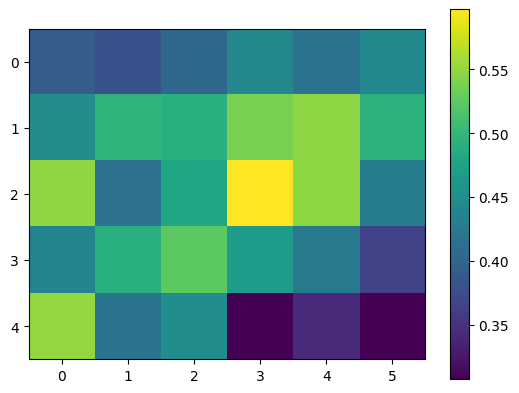

In [ ]:
print(short_windows_1)
print(long_windows_1)
M = np.array([[sharp_ratios_moving_avarge_1[f"_{s}_{ss}"] for s in short_windows_1] for ss in long_windows_1])

plt.imshow(M, interpolation='nearest')
plt.colorbar()
plt.show()

In [ ]:
short_windows_1 = [15, 16, 17, 18, 19]
long_windows_1 = [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]

periods_1 = []
for short_window in short_windows_1:
  for long_window in long_windows_1:
      periods_1.append([short_window, long_window])

In [ ]:
sharp_ratios_moving_avarge_1 = {}

for short_window, long_window in periods_1:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_moving_avarge_train_l = finance_data_moving_avarge_train.copy()
  for i, name in enumerate(finance_names):
    finance_data_moving_avarge_train_l = moving_avarage_cross_over(finance_data_moving_avarge_train_l, name, short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_1[combine_str]}")
#  for name in finance_names:
#    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train, name, 252, combine_str = combine_str)}")


short window 15, long window 45 checked
			 0.04574677627407911 0.09853076236690385
	 sharp ratio portfolie: 0.4642892755029093
short window 15, long window 46 checked
			 0.04946668851503826 0.09398879828262861
	 sharp ratio portfolie: 0.5263040853686591
short window 15, long window 47 checked
			 0.04481884050073936 0.09600568106314303
	 sharp ratio portfolie: 0.46683529562445336
short window 15, long window 48 checked
			 0.03964428072529766 0.09490786546715194
	 sharp ratio portfolie: 0.4177133320843543
short window 15, long window 49 checked
			 0.04767793062456728 0.09001714952205475
	 sharp ratio portfolie: 0.5296538590447801
short window 15, long window 50 checked
			 0.04672971981611419 0.0900008476276781
	 sharp ratio portfolie: 0.519214219064125
short window 15, long window 51 checked
			 0.049328858198426834 0.09088480311805296
	 sharp ratio portfolie: 0.5427624476927361
short window 15, long window 52 checked
			 0.04532186313696154 0.08894753512079244
	 sharp ratio portfo

In [ ]:
sorted_d = dict(sorted(sharp_ratios_moving_avarge_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)


_17_49 0.6375462861430974
_16_50 0.5972823765561419
_18_48 0.5731883613216042
_18_49 0.5694478528800065
_17_48 0.5693691727908873
_16_52 0.5683176279300886
_17_50 0.5650566299380497
_15_56 0.5569593562147719
_15_55 0.5563997288099063
_18_50 0.5477879685652999
_18_45 0.5476494404024744
_15_54 0.5440404129559016
_15_51 0.5427624476927361
_16_48 0.5420485521566812
_19_45 0.5414335605063558
_18_46 0.5387009974651199
_18_47 0.5386302208453699
_16_51 0.5381031886449493
_16_45 0.5378681223663536
_17_47 0.5340083949288758
_15_49 0.5296538590447801
_15_53 0.5290185332734579
_15_46 0.5263040853686591
_16_46 0.5258893850601791
_16_49 0.5235107988803875
_15_50 0.519214219064125
_19_49 0.5142935477547166
_15_52 0.5095347844705712
_16_53 0.509484517656566
_19_48 0.5003594520684491
_17_46 0.49947368145847654
_17_51 0.49637418485829155
_17_52 0.49257891722191854
_16_47 0.49151200973597853
_19_46 0.48156002821822846
_16_56 0.47935302647658673
_17_53 0.47044919096770266
_16_55 0.4669153120373063
_15_47 

[15, 16, 17, 18, 19]
[45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]


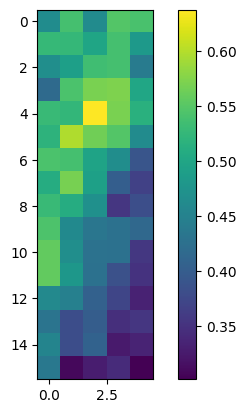

In [ ]:
print(short_windows_1)
print(long_windows_1)
M = np.array([[sharp_ratios_moving_avarge_1[f"_{s}_{ss}"] for s in short_windows_1] for ss in long_windows_1])

plt.imshow(M, interpolation='nearest')
plt.colorbar()
plt.show()

In [ ]:
best_moving_avg = [17, 52]

In [ ]:

for short_window, long_window in [best_moving_avg]:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_moving_avarge_train_l = finance_data_moving_avarge_train.copy()
  for i, name in enumerate(finance_names):
    finance_data_moving_avarge_train_l = moving_avarage_cross_over(finance_data_moving_avarge_train_l, name, short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_1[combine_str]}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    #print(finance_data_moving_avarge_train_l.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


short window 17, long window 52 checked
			 0.04406364763214583 0.08945500120195787
	 sharp ratio portfolie: 0.49257891722191854
			 0.008195079359217879 0.056063564640361226
	 sharp ratio gurkor: 0.14617478235263845
			 0.0431363773176493 0.25783156437889393
	 sharp ratio guitars: 0.16730448586294364
			 0.0063810375129443354 0.18192689082639305
	 sharp ratio slingshots: 0.0350747351529992
			 -0.03251615770310848 0.22880610741720195
	 sharp ratio stocks: -0.14211228043759758
			 -0.034523575720119715 0.2176038510990319
	 sharp ratio sugar: -0.15865333056264694
			 -0.0012368529559455294 0.05041487795796214
	 sharp ratio water: -0.024533491025741747
			 0.033049123737826744 0.21090629825725368
	 sharp ratio tranquillity: 0.15670050639035427


# testar

In [ ]:
for short_window, long_window in [[17, 52]]:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_moving_avarge_train_l = finance_data_moving_avarge_test.copy()
  for i, name in enumerate(finance_names):
    finance_data_moving_avarge_train_l = moving_avarage_cross_over(finance_data_moving_avarge_train_l, name, short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_1[combine_str]}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    #print(finance_data_moving_avarge_train_l.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


short window 17, long window 52 checked
			 0.035344530350515095 0.05433474516244401
	 sharp ratio portfolie: 0.6504959256705065
			 0.03960173781175049 0.033187877761920954
	 sharp ratio gurkor: 1.1932591199666482
			 0.06331222504917382 0.15342018735449928
	 sharp ratio guitars: 0.4126720618772409
			 0.11740807476920188 0.12245287329886674
	 sharp ratio slingshots: 0.9588021220428844
			 0.008369262205557301 0.15057748283222167
	 sharp ratio stocks: 0.05558110049483697
			 -0.003378938541135471 0.17324908532897434
	 sharp ratio sugar: -0.019503355730388805
			 0.049187028268836 0.04935683005340835
	 sharp ratio water: 0.9965597104921728
			 -0.03303104286124351 0.15747229499971646
	 sharp ratio tranquillity: -0.20975780445254186


Plotar

short window 17, long window 52 checked
			 0.035344530350515095 0.05433474516244401


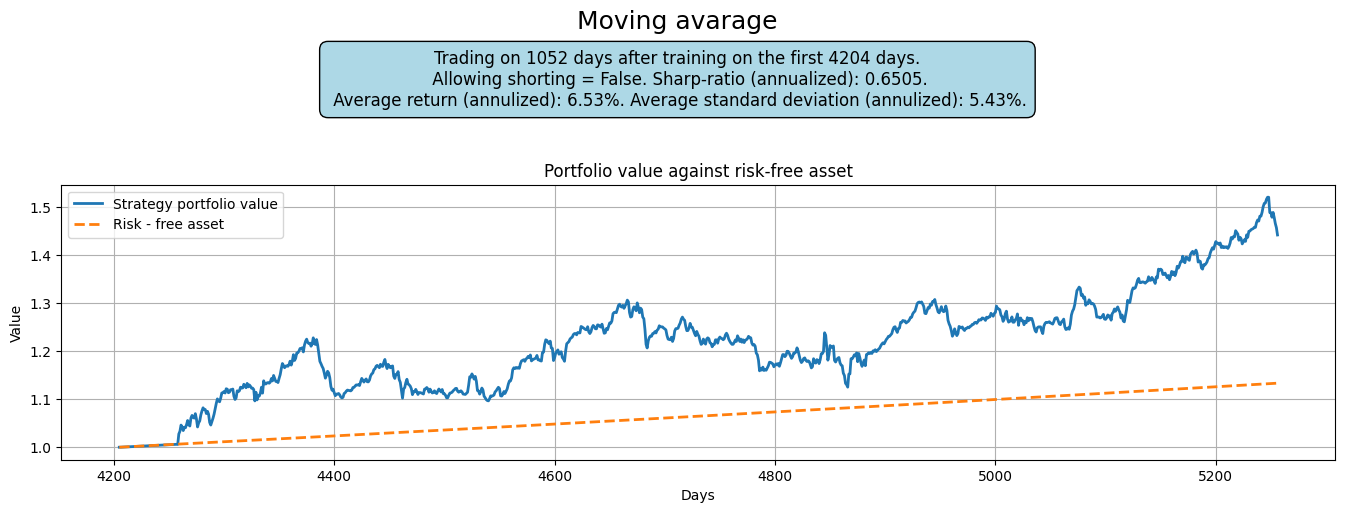

	 sharp ratio portfolie: 0.6504959256705065
			 0.03960173781175049 0.033187877761920954
	 sharp ratio gurkor: 1.1932591199666482
			 0.06331222504917382 0.15342018735449928
	 sharp ratio guitars: 0.4126720618772409
			 0.11740807476920188 0.12245287329886674
	 sharp ratio slingshots: 0.9588021220428844
			 0.008369262205557301 0.15057748283222167
	 sharp ratio stocks: 0.05558110049483697
			 -0.003378938541135471 0.17324908532897434
	 sharp ratio sugar: -0.019503355730388805
			 0.049187028268836 0.04935683005340835
	 sharp ratio water: 0.9965597104921728
			 -0.03303104286124351 0.15747229499971646
	 sharp ratio tranquillity: -0.20975780445254186


In [93]:
for short_window, long_window in [[17, 52]]:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_moving_avarge_train_l = test_data.copy()
  for i, name in enumerate(finance_names):
    finance_data_moving_avarge_train_l = moving_avarage_cross_over(finance_data_moving_avarge_train_l, name, short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)
  title_v = "Moving avarage"
  plot_time_series(finance_data_moving_avarge_train_l['day'].to_numpy(), finance_data_moving_avarge_train_l["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_moving_avarge_2 , mean_v , std_v, title_v)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_2}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    #print(finance_data_moving_avarge_train_l.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


In [16]:
print(finance_data_moving_avarge_train_l.keys())

Index(['Unnamed: 0', 'day', 'gurkor', 'guitars', 'slingshots', 'stocks',
       'sugar', 'water', 'tranquillity', 'gurkor_signal_17_52',
       'gurkor_position_17_52', 'guitars_signal_17_52',
       'guitars_position_17_52', 'slingshots_signal_17_52',
       'slingshots_position_17_52', 'stocks_signal_17_52',
       'stocks_position_17_52', 'sugar_signal_17_52', 'sugar_position_17_52',
       'water_signal_17_52', 'water_position_17_52',
       'tranquillity_signal_17_52', 'tranquillity_position_17_52',
       'gurkorbuy_17_52', 'gurkorsell_17_52', 'gurkorunvalid_17_52',
       'guitarsbuy_17_52', 'guitarssell_17_52', 'guitarsunvalid_17_52',
       'slingshotsbuy_17_52', 'slingshotssell_17_52',
       'slingshotsunvalid_17_52', 'stocksbuy_17_52', 'stockssell_17_52',
       'stocksunvalid_17_52', 'sugarbuy_17_52', 'sugarsell_17_52',
       'sugarunvalid_17_52', 'waterbuy_17_52', 'watersell_17_52',
       'waterunvalid_17_52', 'tranquillitybuy_17_52', 'tranquillitysell_17_52',
       't

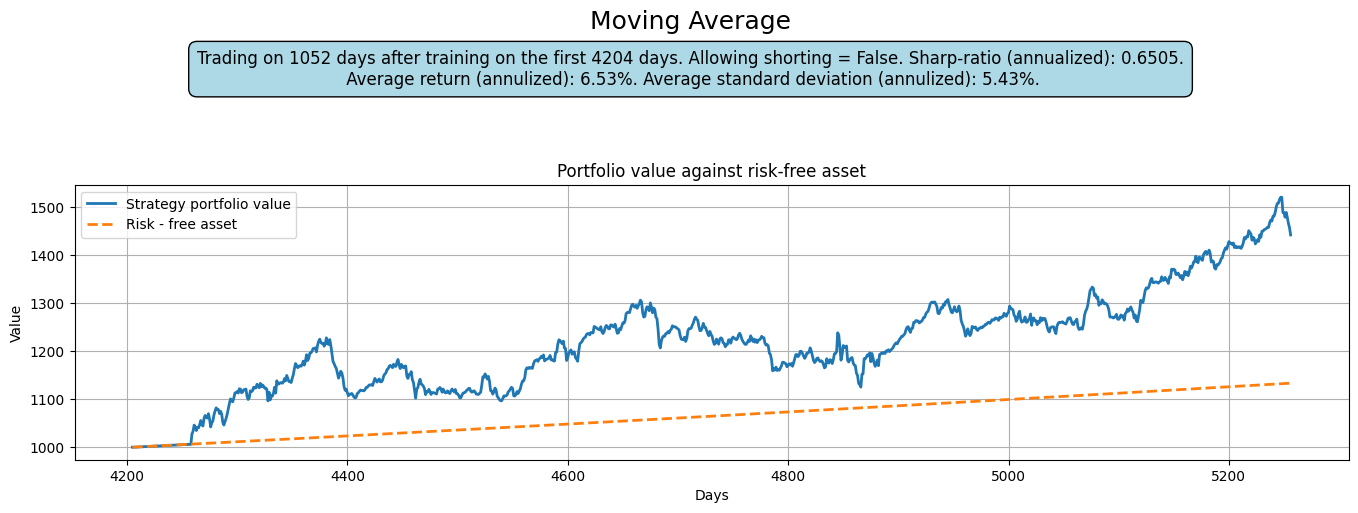

In [31]:
#plot_time_series(finance_data_moving_avarge_train_l['day'].to_numpy(), finance_data_moving_avarge_train_l["portfolie_value_17_52"].to_numpy()*10, 0.65049, 0.035344, 0.05433, "Moving Average")

In [155]:
stringen = """0.04406364763214583 0.08945500120195787
	 sharp ratio portfolie: 0.49257891722191854
			 0.008195079359217879 0.056063564640361226
	 sharp ratio gurkor: 0.14617478235263845
			 0.0431363773176493 0.25783156437889393
	 sharp ratio guitars: 0.16730448586294364
			 0.0063810375129443354 0.18192689082639305
	 sharp ratio slingshots: 0.0350747351529992
			 -0.03251615770310848 0.22880610741720195
	 sharp ratio stocks: -0.14211228043759758
			 -0.034523575720119715 0.2176038510990319
	 sharp ratio sugar: -0.15865333056264694
			 -0.0012368529559455294 0.05041487795796214
	 sharp ratio water: -0.024533491025741747
			 0.033049123737826744 0.21090629825725368
	 sharp ratio tranquillity: 0.15670050639035427"""
stringen = "".join(stringen.split("\t\t\t "))
stringen = "".join(stringen.split(":"))
stringen = "".join(stringen.split("sharp ratio "))
stringen = "".join(stringen.split("\t "))
stringen = stringen.split("\n")
stringen = [stringen[i*2].split(" ") + stringen[2 * i + 1].split(" ") for i in range(len(stringen)//2)]
stringen.append(stringen[0])
stringen.pop(0)
stringen_out = ""
for i in range(len(stringen)):
  print(stringen[i])
  stringen_out += stringen[i][2]+f" & ${float(stringen[i][3]):.2f}$ & ${float(stringen[i][0])*100:.2f} \\%$ & ${100*float(stringen[i][1]):.2f} \\%$ \\\\ \n"
print(stringen_out)

['0.008195079359217879', '0.056063564640361226', 'gurkor', '0.14617478235263845']
['0.0431363773176493', '0.25783156437889393', 'guitars', '0.16730448586294364']
['0.0063810375129443354', '0.18192689082639305', 'slingshots', '0.0350747351529992']
['-0.03251615770310848', '0.22880610741720195', 'stocks', '-0.14211228043759758']
['-0.034523575720119715', '0.2176038510990319', 'sugar', '-0.15865333056264694']
['-0.0012368529559455294', '0.05041487795796214', 'water', '-0.024533491025741747']
['0.033049123737826744', '0.21090629825725368', 'tranquillity', '0.15670050639035427']
['0.04406364763214583', '0.08945500120195787', 'portfolie', '0.49257891722191854']
gurkor & $0.15$ & $0.82 \%$ & $5.61 \%$ \\ 
guitars & $0.17$ & $4.31 \%$ & $25.78 \%$ \\ 
slingshots & $0.04$ & $0.64 \%$ & $18.19 \%$ \\ 
stocks & $-0.14$ & $-3.25 \%$ & $22.88 \%$ \\ 
sugar & $-0.16$ & $-3.45 \%$ & $21.76 \%$ \\ 
water & $-0.02$ & $-0.12 \%$ & $5.04 \%$ \\ 
tranquillity & $0.16$ & $3.30 \%$ & $21.09 \%$ \\ 
portfoli

Buy and hold

In [ ]:
#maximum_in_one_stock = [0]
short_windows_b = [1., 1.25, 1.5, 2., 2.5, 3.]
long_windows_b = [5, 10, 22, 63, 126, 252, 504, 1016]

periods_b = []
for short_window in short_windows_b:
  for long_window in long_windows_b:
      periods_b.append([short_window, long_window])

In [ ]:
sharp_ratios_buy_and_hold_1 = {}

for short_window, long_window in periods_b:
  combine_str = f"_{short_window}_{long_window}_bah"
  finance_data_moving_avarge_train_l = training_data.copy()
  finance_data_moving_avarge_train_l = buy_and_hold_signal(finance_data_moving_avarge_train_l, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, replacing_weight=short_window, rebalancing_interval=long_window, maximum_in_one_stock=1.)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_buy_and_hold_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_buy_and_hold_1[combine_str]}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    #print(finance_data_moving_avarge_train_l.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


short window 1.0, long window 5 checked
			 0.00045799584133019675 0.10040742633330937
	 sharp ratio portfolie: 0.004561374173757307
			 0.004278987638797251 0.06067945067153716
	 sharp ratio gurkor: 0.07051790336665639
			 0.04467123995405056 0.2577223188125787
	 sharp ratio guitars: 0.17333089411839597
			 0.008376737265805978 0.1825840675276257
	 sharp ratio slingshots: 0.045878796431887706
			 -0.03601386856261093 0.23023453429645097
	 sharp ratio stocks: -0.15642253093204217
			 -0.0409580457639878 0.22128420594011575
	 sharp ratio sugar: -0.18509249492063581
			 0.000998290377045158 0.052792023345325644
	 sharp ratio water: 0.018909871487877903
			 0.024905092147140467 0.2136825070759252
	 sharp ratio tranquillity: 0.11655185297077801
short window 1.0, long window 10 checked
			 0.00035154070366031796 0.1003650868374313
	 sharp ratio portfolie: 0.003502619434084028
			 0.004278987638797251 0.06067945067153716
	 sharp ratio gurkor: 0.07051790336665639
			 0.04467123995405056 0.257

In [ ]:
sorted_d = dict(sorted(sharp_ratios_buy_and_hold_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_1.5_504_bah 0.015023961421667552
_2.0_504_bah 0.014510191789878503
_2.5_504_bah 0.014510191789878503
_3.0_504_bah 0.014510191789878503
_1.25_504_bah 0.011613692942868875
_1.0_5_bah 0.004561374173757307
_1.0_10_bah 0.003502619434084028
_1.0_63_bah 2.2369669797021397e-05
_1.0_126_bah -0.0005531991784176646
_1.0_252_bah -0.0007206241315465606
_1.0_504_bah -0.000955729485824608
_1.0_22_bah -0.0009648112132953855
_1.0_1016_bah -0.0010406941333831814
_1.5_126_bah -0.0023322169815393843
_2.0_126_bah -0.0023322169815393843
_2.5_126_bah -0.0023322169815393843
_3.0_126_bah -0.0023322169815393843
_1.25_126_bah -0.0031773806817354654
_1.25_5_bah -0.004377932278267009
_1.5_5_bah -0.004377932278267009
_2.0_5_bah -0.004377932278267009
_2.5_5_bah -0.004377932278267009
_3.0_5_bah -0.004377932278267009
_1.25_252_bah -0.006073314237768296
_2.0_252_bah -0.007523989663054568
_2.5_252_bah -0.007523989663054568
_3.0_252_bah -0.007523989663054568
_1.25_63_bah -0.008155768288213948
_1.5_252_bah -0.00815765195

Buy & hold

In [ ]:
#maximum_in_one_stock = [0]
short_windows_b = [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]
long_windows_b = [63, 126, 252, 126*3, 504, 126*5, 126*6]

periods_b = []
for short_window in short_windows_b:
  for long_window in long_windows_b:
      periods_b.append([short_window, long_window])

In [ ]:
sharp_ratios_buy_and_hold_1 = {}

for short_window, long_window in periods_b:
  combine_str = f"_{short_window}_{long_window}_bah"
  finance_data_moving_avarge_train_l = training_data.copy()
  finance_data_moving_avarge_train_l = buy_and_hold_signal(finance_data_moving_avarge_train_l, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, replacing_weight=short_window, rebalancing_interval=long_window, maximum_in_one_stock=1.)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_buy_and_hold_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_buy_and_hold_1[combine_str]}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    #print(finance_data_moving_avarge_train_l.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


short window 1.1, long window 63 checked
			 -0.0012619548380771474 0.0998290574584513
	 sharp ratio portfolie: -0.012641157496677468
			 0.004278987638797251 0.06067945067153716
	 sharp ratio gurkor: 0.07051790336665639
			 0.04467123995405056 0.2577223188125787
	 sharp ratio guitars: 0.17333089411839597
			 0.008376737265805978 0.1825840675276257
	 sharp ratio slingshots: 0.045878796431887706
			 -0.03601386856261093 0.23023453429645097
	 sharp ratio stocks: -0.15642253093204217
			 -0.0409580457639878 0.22128420594011575
	 sharp ratio sugar: -0.18509249492063581
			 0.000998290377045158 0.052792023345325644
	 sharp ratio water: 0.018909871487877903
			 0.024905092147140467 0.2136825070759252
	 sharp ratio tranquillity: 0.11655185297077801
short window 1.1, long window 126 checked
			 -0.0006761221443999911 0.10005906282182939
	 sharp ratio portfolie: -0.006757230433028651
			 0.004278987638797251 0.06067945067153716
	 sharp ratio gurkor: 0.07051790336665639
			 0.04467123995405056 0

In [ ]:
sorted_d = dict(sorted(sharp_ratios_buy_and_hold_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_1.2_378_bah 0.020582266948809567
_1.1_756_bah 0.018135574281973675
_1.3_378_bah 0.01772372563482113
_1.1_378_bah 0.01745543098376431
_1.5_378_bah 0.016966435905371065
_1.7_378_bah 0.016818171073813913
_1.8_378_bah 0.016818171073813913
_1.9_378_bah 0.016818171073813913
_1.6_378_bah 0.016815382651925368
_1.4_378_bah 0.01646688631727517
_1.6_504_bah 0.016217098736724854
_1.7_504_bah 0.015703865955458005
_1.5_504_bah 0.015023961421667552
_1.8_504_bah 0.014570565919783828
_1.9_504_bah 0.014510191789878503
_1.4_504_bah 0.013292783704179398
_1.3_504_bah 0.011795686007332516
_1.2_504_bah 0.011369930716439046
_1.1_504_bah 0.007873869558970195
_1.5_630_bah 0.00785784944135161
_1.7_630_bah 0.007841965638971212
_1.8_630_bah 0.007841965638971212
_1.9_630_bah 0.007841965638971212
_1.6_630_bah 0.007624192788492764
_1.2_630_bah 0.006966358558022057
_1.4_630_bah 0.006719552252105755
_1.2_756_bah 0.0063077054721438226
_1.3_630_bah 0.006304544524847824
_1.1_630_bah 0.005350047568540807
_1.3_756_bah 0.00

Testar

In [ ]:
for short_window, long_window in [[1.2, 378]]:
  finance_data_moving_avarge_train_l = test_data.copy()
  combine_str = f"_{short_window}_{long_window}_bah"
  finance_data_moving_avarge_train_l = buy_and_hold_signal(finance_data_moving_avarge_train_l, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, replacing_weight=short_window, rebalancing_interval=long_window, maximum_in_one_stock=1.)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_buy_and_hold_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_buy_and_hold_1[combine_str]}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    #print(finance_data_moving_avarge_train_l.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


short window 1.2, long window 378 checked
			 0.03829216432318973 0.07657688468352
	 sharp ratio portfolie: 0.5000486045031096
			 0.041645467961696665 0.033889735488017395
	 sharp ratio gurkor: 1.2288519624598875
			 0.06918405110234829 0.15698687658508878
	 sharp ratio guitars: 0.440699583349247
			 0.12143346237723601 0.12792321254126435
	 sharp ratio slingshots: 0.9492683928498518
			 0.00931033694693779 0.15093811988948985
	 sharp ratio stocks: 0.06168313845272753
			 0.001921635545397029 0.1727363959312623
	 sharp ratio sugar: 0.011124670831743608
			 0.05080900121739822 0.049856535301367175
	 sharp ratio water: 1.0191041336962885
			 -0.013191846115471195 0.17669869260270787
	 sharp ratio tranquillity: -0.07465729327795283


# Plotar

short window 1.2, long window 378 checked
			 0.03829216432318973 0.07657688468352


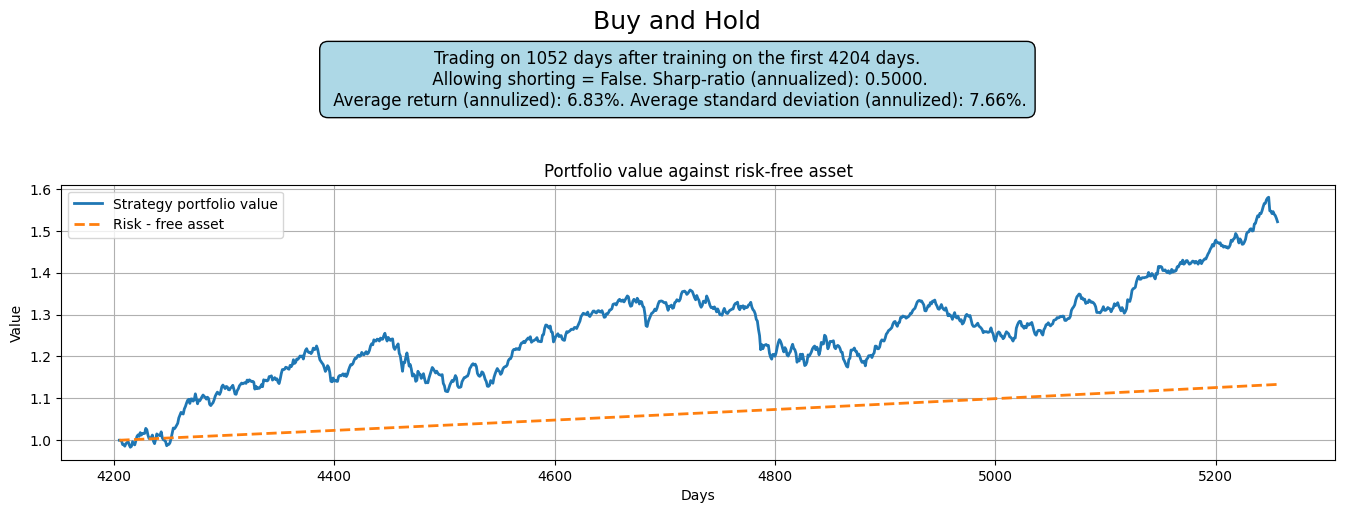

	 sharp ratio portfolie: 0.5000486045031096
			 0.041645467961696665 0.033889735488017395
	 sharp ratio gurkor: 1.2288519624598875
			 0.06918405110234829 0.15698687658508878
	 sharp ratio guitars: 0.440699583349247
			 0.12143346237723601 0.12792321254126435
	 sharp ratio slingshots: 0.9492683928498518
			 0.00931033694693779 0.15093811988948985
	 sharp ratio stocks: 0.06168313845272753
			 0.001921635545397029 0.1727363959312623
	 sharp ratio sugar: 0.011124670831743608
			 0.05080900121739822 0.049856535301367175
	 sharp ratio water: 1.0191041336962885
			 -0.013191846115471195 0.17669869260270787
	 sharp ratio tranquillity: -0.07465729327795283
short window 100000.0, long window None checked
			 0.036424454315034153 0.07888599733833157


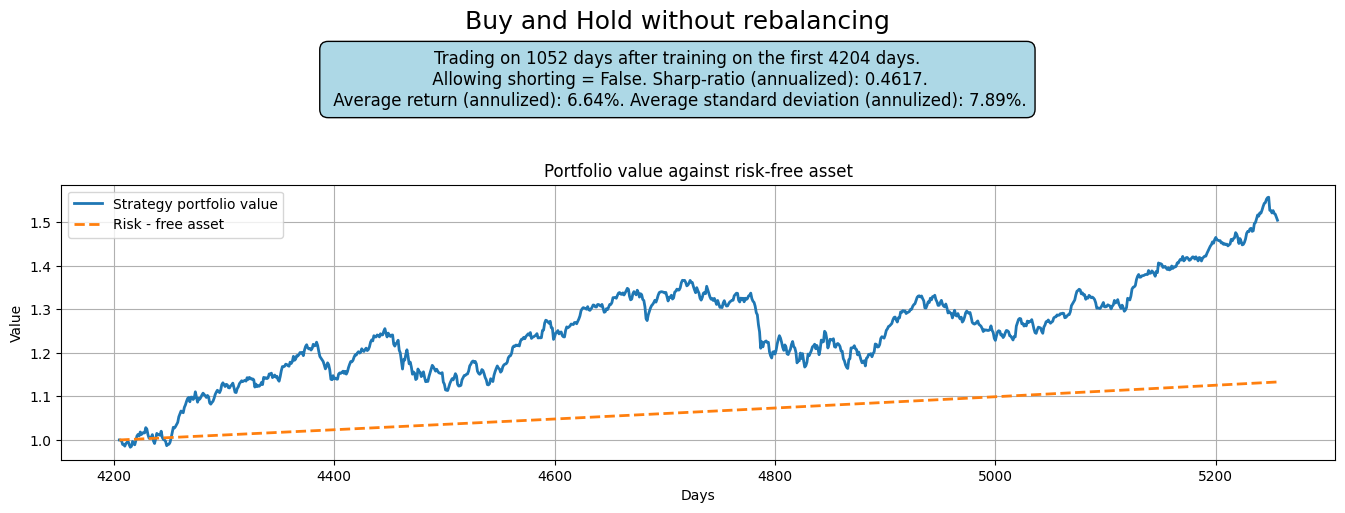

	 sharp ratio portfolie: 0.46173535917679415
			 0.041645467961696665 0.033889735488017395
	 sharp ratio gurkor: 1.2288519624598875
			 0.06918405110234829 0.15698687658508878
	 sharp ratio guitars: 0.440699583349247
			 0.12143346237723601 0.12792321254126435
	 sharp ratio slingshots: 0.9492683928498518
			 0.00931033694693779 0.15093811988948985
	 sharp ratio stocks: 0.06168313845272753
			 0.001921635545397029 0.1727363959312623
	 sharp ratio sugar: 0.011124670831743608
			 0.05080900121739822 0.049856535301367175
	 sharp ratio water: 1.0191041336962885
			 -0.013191846115471195 0.17669869260270787
	 sharp ratio tranquillity: -0.07465729327795283


In [91]:
for short_window, long_window in [[1.2, 378], [100000.0, None]]:
  finance_data_moving_avarge_train_l = test_data.copy()
  combine_str = f"_{short_window}_{long_window}_bah"
  finance_data_moving_avarge_train_l = buy_and_hold_signal(finance_data_moving_avarge_train_l, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, replacing_weight=short_window, rebalancing_interval=long_window, maximum_in_one_stock=1.)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_bd2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)
  title_v = "Buy and Hold" if short_window == 1.2 else "Buy and Hold without rebalancing"
  plot_time_series(finance_data_moving_avarge_train_l['day'].to_numpy(), finance_data_moving_avarge_train_l["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_bd2 , mean_v , std_v, title_v)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd2}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    #print(finance_data_moving_avarge_train_l.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


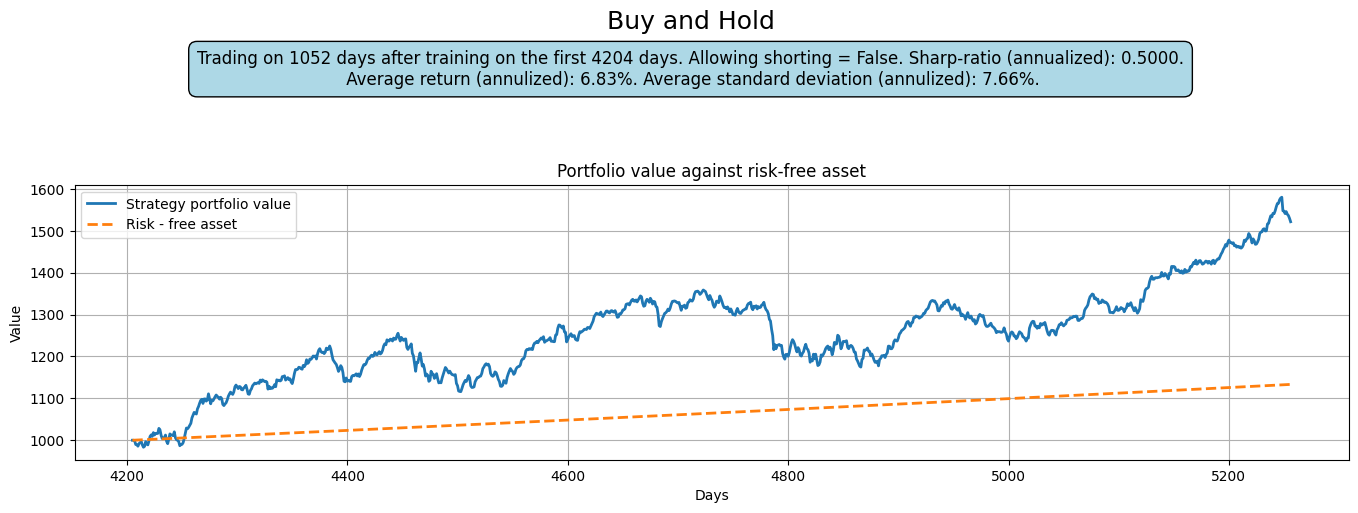

In [34]:
plot_time_series(finance_data_moving_avarge_train_l['day'].to_numpy(), finance_data_moving_avarge_train_l["portfolie_value"+combine_str].to_numpy()*10, 0.500, 0.0382921, 0.076576, "Buy and Hold")

In [35]:
for short_window, long_window in [[10., None]]:
  finance_data_moving_avarge_train_l = test_data.copy()
  combine_str = f"_{short_window}_{long_window}_bah"
  finance_data_moving_avarge_train_l = buy_and_hold_signal(finance_data_moving_avarge_train_l, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, replacing_weight=short_window, rebalancing_interval=long_window, maximum_in_one_stock=1.)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_buy_and_hold2 = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_buy_and_hold2}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    #print(finance_data_moving_avarge_train_l.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


short window 10.0, long window None checked
			 0.036424454315034153 0.07888599733833157
	 sharp ratio portfolie: 0.46173535917679415
			 0.041645467961696665 0.033889735488017395
	 sharp ratio gurkor: 1.2288519624598875
			 0.06918405110234829 0.15698687658508878
	 sharp ratio guitars: 0.440699583349247
			 0.12143346237723601 0.12792321254126435
	 sharp ratio slingshots: 0.9492683928498518
			 0.00931033694693779 0.15093811988948985
	 sharp ratio stocks: 0.06168313845272753
			 0.001921635545397029 0.1727363959312623
	 sharp ratio sugar: 0.011124670831743608
			 0.05080900121739822 0.049856535301367175
	 sharp ratio water: 1.0191041336962885
			 -0.013191846115471195 0.17669869260270787
	 sharp ratio tranquillity: -0.07465729327795283


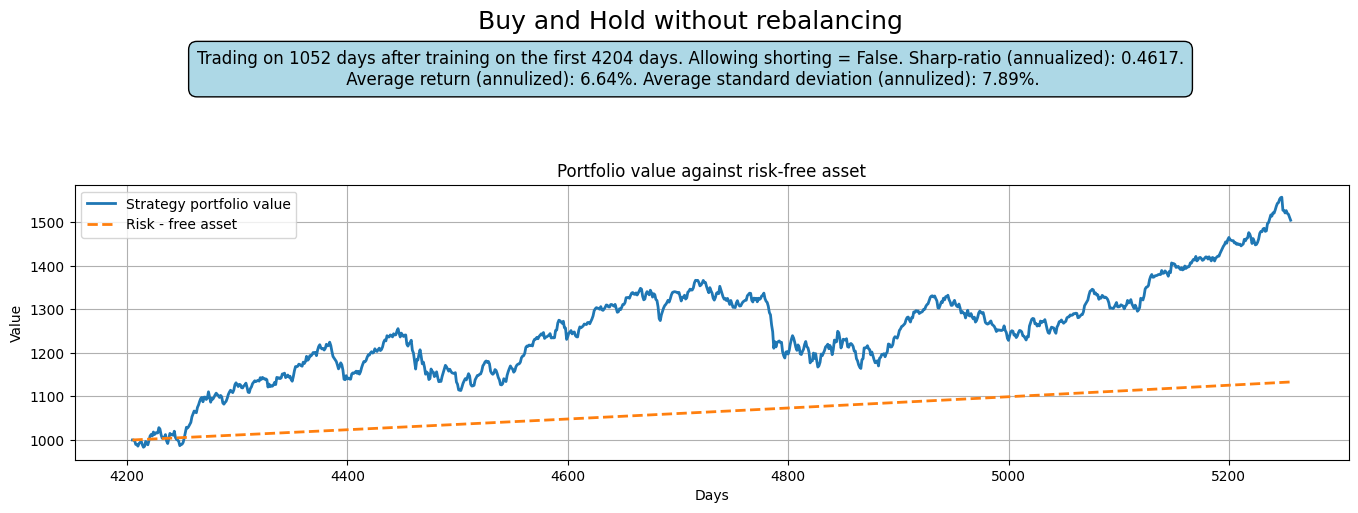

In [37]:
plot_time_series(finance_data_moving_avarge_train_l['day'].to_numpy(), finance_data_moving_avarge_train_l["portfolie_value"+combine_str].to_numpy()*10, 0.46173535917679415, 0.036424454315034153 , 0.07888599733833157, "Buy and Hold without rebalancing")

# channal breakout

In [ ]:
#maximum_in_one_stock = [0]
channal_size = [0.01, 0.01, 0.05, 0.1]
days_above = [2, 3, 4]
sell_after = [5, 10, 25]
above_value = [0.001, 0.005, 0.01, 0.05]
look_back = [5, 10, 15, 20, 25, 50]


periods_c = []
for i1 in channal_size:
  for i2 in days_above:
    for i3 in sell_after:
      for i4 in above_value:
        for i5 in look_back:
          periods_c.append([i1, i2, i3, i4, i5])

In [ ]:
sharp_ratios_chan_1 = {}

for channal_size, days_above, sell_after, above_value, look_back in periods_c:
  combine_str = f"_{channal_size}_{days_above}_{sell_after}_{above_value}_{look_back}"
  finance_data_moving_avarge_train_l = training_data.copy()
  cs = 0
  for name in finance_names:
    finance_data_moving_avarge_train_l, cs_1 = channal_breakout(finance_data_moving_avarge_train_l, name, c = channal_size, d = days_above, k = sell_after, x = above_value, j = look_back, combine_str = combine_str)
    cs += cs_1
  if cs == 0:
    print("no found")
    sharp_ratios_chan_1[combine_str] = -999.
    continue
  print("\t\t\tsa")
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, maximum_in_one_stock=0.5)

  print(f"params {channal_size}, {days_above}, {sell_after}, {above_value}, {look_back} checked", combine_str)
  sharp_ratios_chan_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_chan_1[combine_str]}")
  #for name in finance_names:
  #  finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


Utdata för streaming har trunkerats till de sista 5000 raderna.
4135 0
4135 0
4075 60
4135 0
			sa
params 0.01, 4, 10, 0.005, 15 checked _0.01_4_10_0.005_15
			 -0.0006161397323182358 0.0042551653698119215
	 sharp ratio portfolie: -0.14479806982107235
4090 40
4130 0
4130 0
4130 0
4130 0
4100 30
4130 0
			sa
params 0.01, 4, 10, 0.005, 20 checked _0.01_4_10_0.005_20
			 -0.00037651902924473545 0.0026475262101632755
	 sharp ratio portfolie: -0.14221541142798172
4105 20
4125 0
4125 0
4125 0
4125 0
4125 0
4125 0
			sa
params 0.01, 4, 10, 0.005, 25 checked _0.01_4_10_0.005_25
			 -0.0002641844104406976 0.0015661843471535494
	 sharp ratio portfolie: -0.1686802775936547
4100 0
4100 0
4100 0
4100 0
4100 0
4100 0
4100 0
no found
4085 60
3916 229
4065 80
4115 30
3999 146
4135 10
3895 250
			sa
params 0.01, 4, 10, 0.01, 5 checked _0.01_4_10_0.01_5
			 -0.005419909248621483 0.029190716854464276
	 sharp ratio portfolie: -0.18567235863522794
4120 20
4130 10
4140 0
4140 0
4130 10
4140 0
4120 20
			sa


In [ ]:
sorted_d = dict(sorted(sharp_ratios_chan_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_0.05_2_25_0.001_15 0.599724173712704
_0.05_4_10_0.001_25 0.46611444510719924
_0.05_3_25_0.001_15 0.46176294944686846
_0.05_4_10_0.001_20 0.43544008845188426
_0.01_2_10_0.001_25 0.43254975362347825
_0.01_2_5_0.001_20 0.4235057569769714
_0.1_2_5_0.05_5 0.4070829938540872
_0.1_2_10_0.05_5 0.40184677692137916
_0.1_4_10_0.001_50 0.39965075538275724
_0.01_3_5_0.01_10 0.38735204223352343
_0.1_3_25_0.001_25 0.3821018122822607
_0.05_3_5_0.05_5 0.38070987615969
_0.1_2_25_0.05_5 0.37655318467746807
_0.01_2_10_0.01_15 0.37175749602884234
_0.1_3_5_0.05_5 0.3707643967826792
_0.05_4_25_0.001_20 0.36781161445472205
_0.05_2_25_0.005_15 0.3675496279399401
_0.1_2_10_0.05_10 0.3633468847398535
_0.1_2_10_0.05_15 0.3633468847398535
_0.05_4_25_0.001_25 0.36248958894865196
_0.1_2_5_0.05_10 0.36215332457241933
_0.1_2_5_0.05_15 0.36215332457241933
_0.05_4_25_0.001_15 0.3549212114677803
_0.05_2_25_0.01_15 0.35405700889879654
_0.1_4_10_0.005_50 0.3537659469015692
_0.01_2_5_0.01_10 0.35362968170495535
_0.01_2_10_

In [ ]:
#maximum_in_one_stock = [0]
channal_size = [0.01, 0.05, 0.1]
days_above = [2, 3, 4]
sell_after = [5, 10, 25]
above_value = [0.001, 0.01, 0.05]
look_back = [5, 10, 15, 20, 25]


periods_c2 = []
for i1 in channal_size:
  for i2 in days_above:
    for i3 in sell_after:
      for i4 in above_value:
        for i5 in look_back:
          periods_c2.append([i1, i2, i3, i4, i5])

In [ ]:
sharp_ratios_chan_2 = {}

for channal_size, days_above, sell_after, above_value, look_back in periods_c2:
  combine_str = f"_{channal_size}_{days_above}_{sell_after}_{above_value}_{look_back}"
  finance_data_moving_avarge_train_l = training_data.copy()
  cs = 0
  for name in finance_names:
    finance_data_moving_avarge_train_l, cs_1 = channal_breakout(finance_data_moving_avarge_train_l, name, c = channal_size, d = days_above, k = sell_after, x = above_value, j = look_back, combine_str = combine_str)
    cs += cs_1
  if cs == 0:
    print("no found")
    sharp_ratios_chan_2[combine_str] = -999.
    continue
  print("\t\t\tsa")
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, maximum_in_one_stock=0.5)

  print(f"params {channal_size}, {days_above}, {sell_after}, {above_value}, {look_back} checked", combine_str)
  sharp_ratios_chan_2[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_chan_2[combine_str]}")
  #for name in finance_names:
  #  finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


2556 1591
3666 481
3674 473
4051 96
3841 306
2487 1660
3629 518
			sa
params 0.01, 2, 5, 0.001, 5 checked _0.01_2_5_0.001_5
			 -0.01761162510861801 0.0480443395962461
	 sharp ratio portfolie: -0.36657024025352775
3494 648
4126 16
4101 41
4142 0
4127 15
3237 905
4126 16
			sa
params 0.01, 2, 5, 0.001, 10 checked _0.01_2_5_0.001_10
			 -0.0006237118144547896 0.017739507438910954
	 sharp ratio portfolie: -0.03515947760120446
3884 253
4137 0
4132 5
4137 0
4137 0
3721 416
4132 5
			sa
params 0.01, 2, 5, 0.001, 15 checked _0.01_2_5_0.001_15
			 -0.0001403771750730059 0.008969740294379722
	 sharp ratio portfolie: -0.015650082440063925
4036 96
4132 0
4132 0
4132 0
4132 0
3990 142
4132 0
			sa
params 0.01, 2, 5, 0.001, 20 checked _0.01_2_5_0.001_20
			 0.0014355305234521043 0.003389636385816977
	 sharp ratio portfolie: 0.4235057569769714
4079 48
4127 0
4127 0
4127 0
4127 0
4081 46
4127 0
			sa
params 0.01, 2, 5, 0.001, 25 checked _0.01_2_5_0.001_25
			 0.0009585722639138528 0.00317938842399906

In [ ]:
sorted_d = dict(sorted(sharp_ratios_chan_2.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_0.05_2_25_0.001_15 0.599724173712704
_0.05_4_10_0.001_25 0.46611444510719924
_0.05_3_25_0.001_15 0.46176294944686846
_0.05_4_10_0.001_20 0.43544008845188426
_0.01_2_10_0.001_25 0.43254975362347825
_0.01_2_5_0.001_20 0.4235057569769714
_0.1_2_5_0.05_5 0.4070829938540872
_0.1_2_10_0.05_5 0.40184677692137916
_0.01_3_5_0.01_10 0.38735204223352343
_0.1_3_25_0.001_25 0.3821018122822607
_0.05_3_5_0.05_5 0.38070987615969
_0.1_2_25_0.05_5 0.37655318467746807
_0.01_2_10_0.01_15 0.37175749602884234
_0.1_3_5_0.05_5 0.3707643967826792
_0.05_4_25_0.001_20 0.36781161445472205
_0.1_2_10_0.05_10 0.3633468847398535
_0.1_2_10_0.05_15 0.3633468847398535
_0.05_4_25_0.001_25 0.36248958894865196
_0.1_2_5_0.05_10 0.36215332457241933
_0.1_2_5_0.05_15 0.36215332457241933
_0.05_4_25_0.001_15 0.3549212114677803
_0.05_2_25_0.01_15 0.35405700889879654
_0.01_2_5_0.01_10 0.35362968170495535
_0.01_2_10_0.01_10 0.34882542998280175
_0.1_2_25_0.05_10 0.3426328107139731
_0.1_2_25_0.05_15 0.3426328107139731
_0.05_2_10_0.0

testar

In [143]:
#maximum_in_one_stock = [0]
channal_size = [0.05] #_0.01_2_10_0.001_25
days_above = [2]#4] _0.05_2_25_0.001_15
sell_after = [25]
above_value = [0.001]
look_back = [15]


best_cb_hps = []
for i1 in channal_size:
  for i2 in days_above:
    for i3 in sell_after:
      for i4 in above_value:
        for i5 in look_back:
          best_cb_hps.append([i1, i2, i3, i4, i5])

In [144]:
sharp_ratios_chan_3 = {}

for channal_size, days_above, sell_after, above_value, look_back in best_cb_hps:
  combine_str = f"_{channal_size}_{days_above}_{sell_after}_{above_value}_{look_back}"
  finance_data_moving_avarge_train_l = training_data.copy()
  cs = 0
  for name in finance_names:
    finance_data_moving_avarge_train_l, cs_1 = channal_breakout(finance_data_moving_avarge_train_l, name, c = channal_size, d = days_above, k = sell_after, x = above_value, j = look_back, combine_str = combine_str)
    cs += cs_1
  if cs == 0:
    print("no found")
    sharp_ratios_chan_3[combine_str] = -999.
    continue
  print("\t\t\tsa")
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, maximum_in_one_stock=0.5)

  print(f"params {channal_size}, {days_above}, {sell_after}, {above_value}, {look_back} checked", combine_str)
  sharp_ratios_chan_3[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_chan_3[combine_str]}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


1820 2317
2285 1852
2286 1851
2987 1150
2722 1415
1690 2447
2374 1763
			sa
params 0.05, 2, 25, 0.001, 15 checked _0.05_2_25_0.001_15
			 0.040861974340283526 0.06813461276259697
	 sharp ratio portfolie: 0.599724173712704
			 0.00833590478468843 0.0560889624286176
	 sharp ratio gurkor: 0.1486193436952455
			 0.043235112364492415 0.257997049273699
	 sharp ratio guitars: 0.16757987149932857
			 0.005659608289796463 0.1817148567486206
	 sharp ratio slingshots: 0.031145545229831217
			 -0.03358834394083782 0.2297019772249848
	 sharp ratio stocks: -0.14622575019430173
			 -0.039331910935140976 0.2207582511864357
	 sharp ratio sugar: -0.1781673424379695
			 -5.42906735554233e-05 0.051741490851592575
	 sharp ratio water: -0.0010492676701400509
			 0.02594992954876431 0.21319585731520413
	 sharp ratio tranquillity: 0.12171873260369248


In [150]:
sharp_ratios_chan_3 = {}
print(best_cb_hps) #[[0.05, 4, 5, 0.001, 15]]
for channal_size, days_above, sell_after, above_value, look_back in best_cb_hps:
  combine_str = f"_{channal_size}_{days_above}_{sell_after}_{above_value}_{look_back}"
  finance_data_moving_avarge_train_l = test_data.copy()
  cs = 0

  for name in finance_names:
    finance_data_moving_avarge_train_l, cs_1 = channal_breakout(finance_data_moving_avarge_train_l, name, c = channal_size, d = days_above, k = sell_after, x = above_value, j = look_back, combine_str = combine_str)
    cs += cs_1
  if cs == 0:
    print("no found")
    sharp_ratios_chan_3[combine_str] = -999.
    continue
  print("\t\t\tsa")
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, rebalancing_interval=50000, maximum_in_one_stock=0.5)

  print(f"params {channal_size}, {days_above}, {sell_after}, {above_value}, {look_back} checked", combine_str)
  sharp_ratios_chan_3[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_chan_3[combine_str]}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


[[0.05, 2, 25, 0.001, 15]]
379 656
672 363
660 375
704 331
585 450
421 614
650 385
			sa
params 0.05, 2, 25, 0.001, 15 checked _0.05_2_25_0.001_15
			 0.0022182845920406358 0.09247375585364871
	 sharp ratio portfolie: 0.023988261010522257
			 0.04185492968366176 0.03344610155858832
	 sharp ratio gurkor: 1.251414297428461
			 0.058713693712832554 0.152389358341358
	 sharp ratio guitars: 0.38528736095411353
			 0.10867772000742394 0.11860504188686281
	 sharp ratio slingshots: 0.916299326558912
			 0.008318874573955824 0.15073395183657906
	 sharp ratio stocks: 0.05518912277291637
			 -0.008988775214553482 0.17437310564787467
	 sharp ratio sugar: -0.05154909170858735
			 0.05086571168942703 0.049700661754879534
	 sharp ratio water: 1.0234413364613422
			 -0.031553220385569625 0.15944001654055848
	 sharp ratio tranquillity: -0.19790025785366808


In [ ]:
sorted_d = dict(sorted(sharp_ratios_chan_3.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_0.05_4_5_0.001_15 0.42391945478302695


785 248
891 142
917 116
968 65
875 158
801 232
948 85
			sa
			 0.02415145387089357 0.05702183059418495


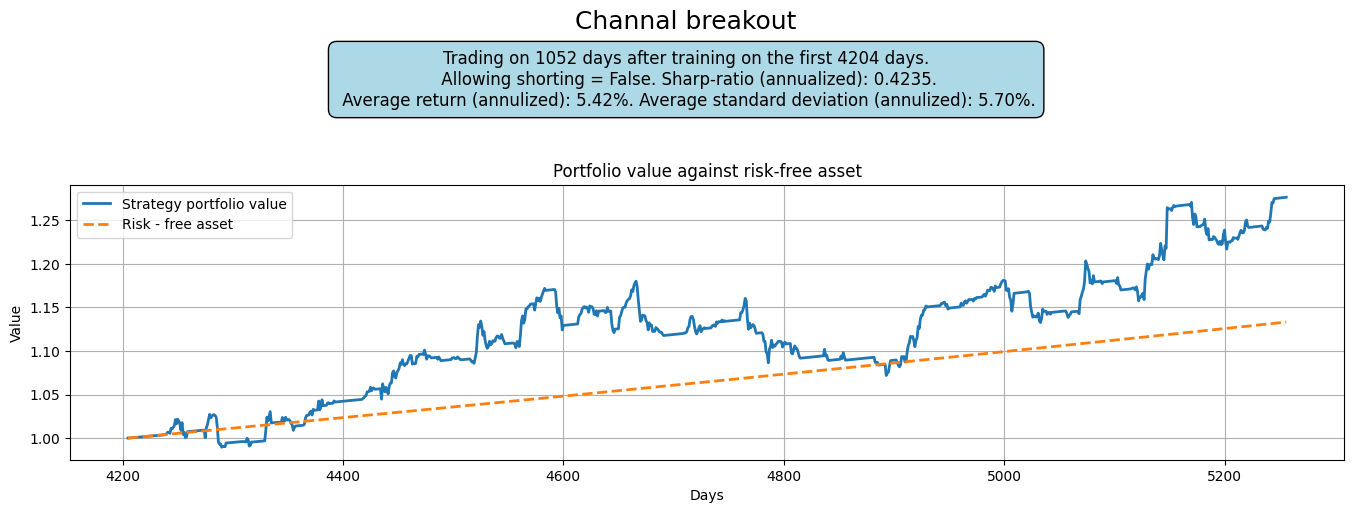

params 0.05, 4, 5, 0.001, 15 checked _0.05_4_5_0.001_15
	 sharp ratio portfolie: 0.4235475013556741
			 0.04193216113435609 0.0334597129015337
	 sharp ratio gurkor: 1.2532134169159006
			 0.0592663678847601 0.15252380847985125
	 sharp ratio guitars: 0.3885712563529996
			 0.1081900335598531 0.11870186219565987
	 sharp ratio slingshots: 0.911443439543688
			 0.007442387369260312 0.15093088704608534
	 sharp ratio stocks: 0.049309902796687656
			 -0.012074478194617839 0.17555981432729245
	 sharp ratio sugar: -0.06877700481106482
			 0.05053501904382328 0.04963227833519887
	 sharp ratio water: 1.0181885808772997
			 -0.038604240197360286 0.15413006117928132
	 sharp ratio tranquillity: -0.25046535310497625


In [95]:
#sharp_ratios_chan_3 = {}
#print(best_cb_hps) #[[0.05, 4, 5, 0.001, 15]]
for channal_size, days_above, sell_after, above_value, look_back in [[0.05, 4, 5, 0.001, 15]]:
  combine_str = f"_{channal_size}_{days_above}_{sell_after}_{above_value}_{look_back}"
  finance_data_moving_avarge_train_l = test_data.copy()
  cs = 0

  for name in finance_names:
    finance_data_moving_avarge_train_l, cs_1 = channal_breakout(finance_data_moving_avarge_train_l, name, c = channal_size, d = days_above, k = sell_after, x = above_value, j = look_back, combine_str = combine_str)
    cs += cs_1
  if cs == 0:
    print("no found")
    #sharp_ratios_chan_3[combine_str] = -999.
    continue
  print("\t\t\tsa")
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, rebalancing_interval=50000, maximum_in_one_stock=0.5)

  sharp_ratios_bd2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)
  title_v = "Channal breakout"
  plot_time_series(finance_data_moving_avarge_train_l['day'].to_numpy(), finance_data_moving_avarge_train_l["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_bd2 , mean_v , std_v, title_v)

  print(f"params {channal_size}, {days_above}, {sell_after}, {above_value}, {look_back} checked", combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd2}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


Buy dip ...

In [ ]:
#maximum_in_one_stock = [0]
days_look_backs = [5, 10, 15]#, 20, 30, 40, 50]
streangth_volis = [1.2, 1.4, 1.6, 1.8, 2.0]#, 2.2, 2.4]
days_max_to_sells = [5, 10, 20]#, 30]

print(len(days_look_backs) * len(streangth_volis) * len(days_max_to_sells))
best_bd_hps = []
for i1 in days_look_backs:
  for i2 in streangth_volis:
    for i3 in days_max_to_sells:
          best_bd_hps.append([i1, i2, i3])

45


In [ ]:
sharp_ratios_bd_1 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_bd_hps:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_moving_avarge_train_l = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_moving_avarge_train_l = buy_dip(finance_data_moving_avarge_train_l, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_1[combine_str]}")
  #for name in finance_names:
  #  finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


597
1281
632
1269
636
1217
635
1357
680
1420
603
1239
637
1341
params 5 1.2 5 checked _5_1.2_5_bd
			 0.07768790734954155 0.09678967235116945
	 sharp ratio portfolie: 0.8026466611817484
597
1284
632
1273
636
1217
635
1360
680
1420
603
1245
637
1341
params 5 1.2 10 checked _5_1.2_10_bd
			 0.07805535880423355 0.09705790687321748
	 sharp ratio portfolie: 0.8042143223446376
597
1284
632
1273
636
1217
635
1360
680
1420
603
1245
637
1341
params 5 1.2 20 checked _5_1.2_20_bd
			 0.07805535880423355 0.09705790687321748
	 sharp ratio portfolie: 0.8042143223446376
353
989
373
1042
381
983
349
1051
421
1157
349
944
391
1084
params 5 1.4 5 checked _5_1.4_5_bd
			 0.08391531675758988 0.10517728498910742
	 sharp ratio portfolie: 0.7978463863778238
353
1000
373
1062
381
995
349
1078
421
1173
349
967
391
1092
params 5 1.4 10 checked _5_1.4_10_bd
			 0.0857699155620286 0.10808197139140331
	 sharp ratio portfolie: 0.7935635745523664
353
1000
373
1062
381
995
349
1078
421
1173
349
967
391
1092
params 5 

In [ ]:
sorted_d = dict(sorted(sharp_ratios_bd_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_5_1.2_10_bd 0.8042143223446376
_5_1.2_20_bd 0.8042143223446376
_5_1.2_5_bd 0.8026466611817484
_5_1.4_5_bd 0.7978463863778238
_5_1.4_10_bd 0.7935635745523664
_5_1.4_20_bd 0.7935635745523664
_10_1.6_5_bd 0.558490685965263
_5_1.6_20_bd 0.5528074670202677
_5_1.6_10_bd 0.5393836715232889
_10_1.8_5_bd 0.5370285583328137
_10_1.2_20_bd 0.4288617958835668
_10_1.2_10_bd 0.4238360418980009
_10_1.8_20_bd 0.42349716611724153
_10_1.2_5_bd 0.4220150443607434
_10_2.0_20_bd 0.3932353145067635
_10_1.4_5_bd 0.3916124639359454
_10_1.8_10_bd 0.3790936681825946
_5_1.6_5_bd 0.35447123832811117
_10_1.4_20_bd 0.3523592358737966
_10_1.4_10_bd 0.34789197848884756
_10_2.0_10_bd 0.3175249886538895
_10_1.6_10_bd 0.30766472044437265
_10_1.6_20_bd 0.2935103424184002
_10_2.0_5_bd 0.20386426063754384
_15_1.6_5_bd 0.19405042688577995
_15_1.2_20_bd 0.17561380263977033
_15_1.2_10_bd 0.16312733202349528
_15_1.2_5_bd 0.11928928294065688
_15_1.6_20_bd 0.08761162556878933
_15_1.6_10_bd 0.0857678319357213
_15_1.4_5_bd 0.06824

In [ ]:
#maximum_in_one_stock = [0]
days_look_backs = [4, 5, 6, 7, 8, 9, 10]
streangth_volis = [1., 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7]
days_max_to_sells = [5, 10, 20, 30]

print(len(days_look_backs) * len(streangth_volis) * len(days_max_to_sells))
best_bd_hps = []
for i1 in days_look_backs:
  for i2 in streangth_volis:
    for i3 in days_max_to_sells:
          best_bd_hps.append([i1, i2, i3])

224


In [ ]:
sharp_ratios_bd_1 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_bd_hps:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_moving_avarge_train_l = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_moving_avarge_train_l = buy_dip(finance_data_moving_avarge_train_l, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_1[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_1[combine_str]}")
  #for name in finance_names:
  #  finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


813
1403
840
1364
864
1381
890
1497
902
1555
809
1347
866
1470
params 4 1.0 5 checked _4_1.0_5_bd
			 0.06893600833056718 0.10486760093494227
	 sharp ratio portfolie: 0.657362309387946
813
1403
840
1364
864
1381
890
1497
902
1555
809
1347
866
1470
params 4 1.0 10 checked _4_1.0_10_bd
			 0.06893600833056718 0.10486760093494227
	 sharp ratio portfolie: 0.657362309387946
813
1403
840
1364
864
1381
890
1497
902
1555
809
1347
866
1470
params 4 1.0 20 checked _4_1.0_20_bd
			 0.06893600833056718 0.10486760093494227
	 sharp ratio portfolie: 0.657362309387946
813
1403
840
1364
864
1381
890
1497
902
1555
809
1347
866
1470
params 4 1.0 30 checked _4_1.0_30_bd
			 0.06893600833056718 0.10486760093494227
	 sharp ratio portfolie: 0.657362309387946
666
1292
692
1261
714
1277
700
1381
754
1436
683
1258
722
1366
params 4 1.1 5 checked _4_1.1_5_bd
			 0.06585097273891277 0.10616659980946808
	 sharp ratio portfolie: 0.6202607303718142
666
1293
692
1261
714
1277
700
1382
754
1436
683
1258
722
1366
param

In [ ]:
sorted_d = dict(sorted(sharp_ratios_bd_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_5_1.3_10_bd 0.8338017506267604
_5_1.3_20_bd 0.8338017506267604
_5_1.3_30_bd 0.8338017506267604
_5_1.3_5_bd 0.828763719819972
_8_1.5_5_bd 0.8197190360208573
_5_1.2_10_bd 0.8042143223446376
_5_1.2_20_bd 0.8042143223446376
_5_1.2_30_bd 0.8042143223446376
_5_1.2_5_bd 0.8026466611817484
_5_1.4_5_bd 0.7978463863778238
_5_1.4_10_bd 0.7935635745523664
_5_1.4_20_bd 0.7935635745523664
_5_1.4_30_bd 0.7935635745523664
_5_1.0_10_bd 0.7829817130610364
_5_1.0_20_bd 0.7829817130610364
_5_1.0_30_bd 0.7829817130610364
_5_1.0_5_bd 0.7791359906450762
_8_1.5_10_bd 0.7775529723012852
_8_1.5_20_bd 0.7718441651335292
_8_1.5_30_bd 0.7718441651335292
_8_1.6_10_bd 0.767674375778078
_5_1.1_10_bd 0.7596447260501289
_5_1.1_20_bd 0.7596447260501289
_5_1.1_30_bd 0.7596447260501289
_8_1.6_20_bd 0.7539043541473056
_8_1.6_30_bd 0.7539043541473056
_5_1.1_5_bd 0.7451824674667349
_5_1.5_5_bd 0.7321397210071763
_5_1.5_20_bd 0.7164655331886397
_5_1.5_30_bd 0.7164655331886397
_5_1.5_10_bd 0.7121178308903511
_4_1.3_10_bd 0.70

[4, 5, 6, 7, 8, 9, 10]
[1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7]
[5, 10, 20, 30]


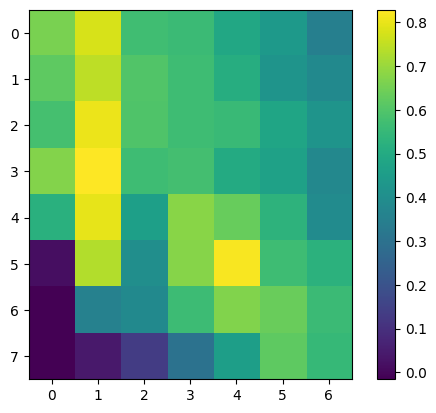

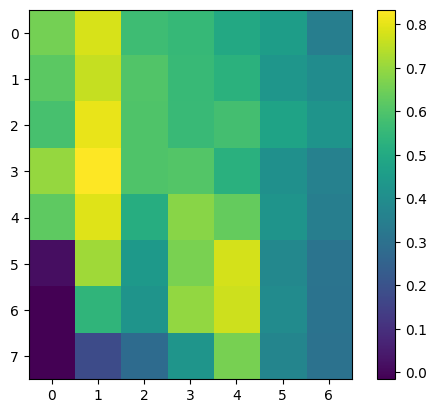

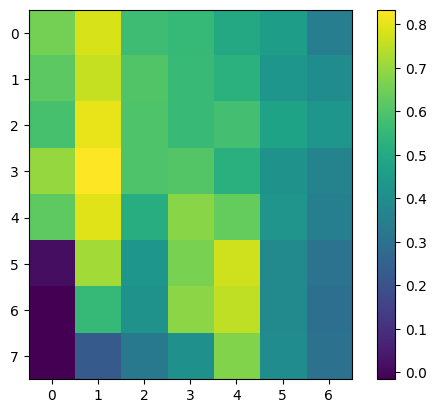

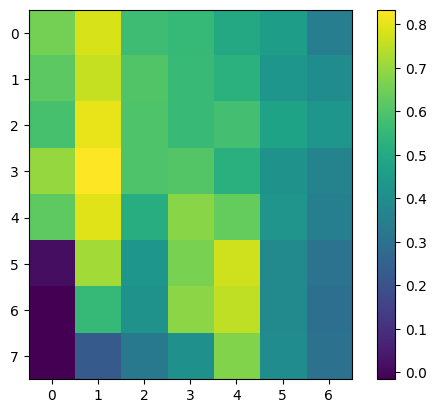

In [ ]:
print(days_look_backs)
print(streangth_volis)
print(days_max_to_sells)

for sss in days_max_to_sells:
  M = np.array([[sharp_ratios_bd_1[f"_{s}_{ss}_{sss}_bd"] for s in days_look_backs] for ss in streangth_volis])

  plt.imshow(M, interpolation='nearest')
  plt.colorbar()
  plt.show()

print("\n")

In [ ]:
#maximum_in_one_stock = [0]
days_look_backs1 = [4, 5, 6, 7, 8, 9]
streangth_volis1 = [1.2, 1.25, 1.3, 1.45, 1.4, 1.5, 1.55]
days_max_to_sells1 = [5, 10, 20, 30]

print(len(days_look_backs1) * len(streangth_volis1) * len(days_max_to_sells1))
best_bd_hps1 = []
for i1 in days_look_backs1:
  for i2 in streangth_volis1:
    for i3 in days_max_to_sells1:
          best_bd_hps1.append([i1, i2, i3])

168


In [ ]:
sharp_ratios_bd_2 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_bd_hps1:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_moving_avarge_train_l = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_moving_avarge_train_l = buy_dip(finance_data_moving_avarge_train_l, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_2[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_2[combine_str]}")
  #for name in finance_names:
  #  finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


515
1148
527
1124
534
1112
541
1241
607
1322
511
1122
571
1210
params 4 1.2 5 checked _4_1.2_5_bd
			 0.06232855918707933 0.10769643859026744
	 sharp ratio portfolie: 0.5787429928320024
515
1155
527
1124
534
1112
541
1246
607
1322
511
1124
571
1211
params 4 1.2 10 checked _4_1.2_10_bd
			 0.063565375080854 0.10836191644032603
	 sharp ratio portfolie: 0.586602536841058
515
1155
527
1124
534
1112
541
1246
607
1322
511
1124
571
1211
params 4 1.2 20 checked _4_1.2_20_bd
			 0.063565375080854 0.10836191644032603
	 sharp ratio portfolie: 0.586602536841058
515
1155
527
1124
534
1112
541
1246
607
1322
511
1124
571
1211
params 4 1.2 30 checked _4_1.2_30_bd
			 0.063565375080854 0.10836191644032603
	 sharp ratio portfolie: 0.586602536841058
424
1030
460
1052
453
1023
451
1118
527
1239
448
1028
483
1088
params 4 1.25 5 checked _4_1.25_5_bd
			 0.07607153305709283 0.11410739709290094
	 sharp ratio portfolie: 0.6666660969854472
424
1039
460
1052
453
1026
451
1127
527
1240
448
1034
483
1093
params 4

In [ ]:
sorted_d = dict(sorted(sharp_ratios_bd_2.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_5_1.3_10_bd 0.8338017506267604
_5_1.3_20_bd 0.8338017506267604
_5_1.3_30_bd 0.8338017506267604
_5_1.3_5_bd 0.828763719819972
_8_1.5_5_bd 0.8197190360208573
_5_1.2_10_bd 0.8042143223446376
_5_1.2_20_bd 0.8042143223446376
_5_1.2_30_bd 0.8042143223446376
_5_1.2_5_bd 0.8026466611817484
_5_1.4_5_bd 0.7978463863778238
_5_1.4_10_bd 0.7935635745523664
_5_1.4_20_bd 0.7935635745523664
_5_1.4_30_bd 0.7935635745523664
_8_1.5_10_bd 0.7775529723012852
_5_1.25_10_bd 0.7724373571414735
_5_1.25_20_bd 0.7724373571414735
_5_1.25_30_bd 0.7724373571414735
_8_1.5_20_bd 0.7718441651335292
_8_1.5_30_bd 0.7718441651335292
_5_1.25_5_bd 0.7714558575952862
_5_1.45_5_bd 0.7448550806129555
_8_1.55_5_bd 0.7411742155002807
_8_1.55_20_bd 0.7391617894756235
_8_1.55_30_bd 0.7391617894756235
_5_1.55_20_bd 0.7373132907662456
_5_1.55_30_bd 0.7373132907662456
_5_1.45_10_bd 0.7352538107102512
_5_1.45_20_bd 0.7351780221480222
_5_1.45_30_bd 0.7351780221480222
_8_1.55_10_bd 0.73227288011931
_5_1.5_5_bd 0.7321397210071763
_5_1.

[4, 5, 6, 7, 8, 9]
[1.2, 1.25, 1.3, 1.4, 1.45, 1.5, 1.55]
[5, 10, 20, 30]


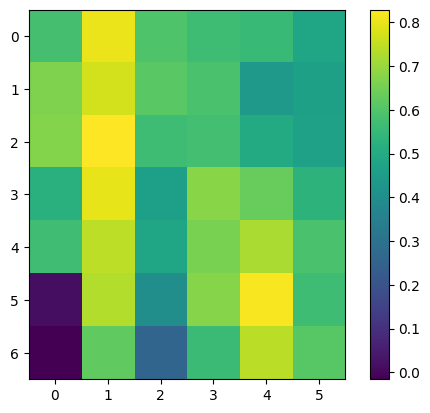

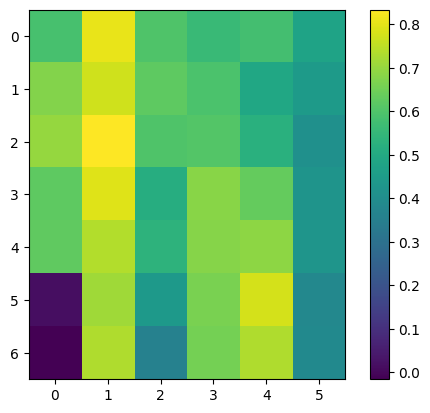

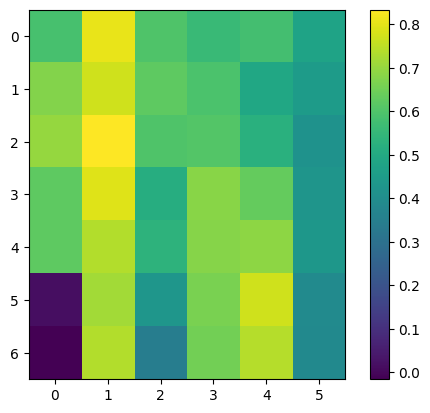

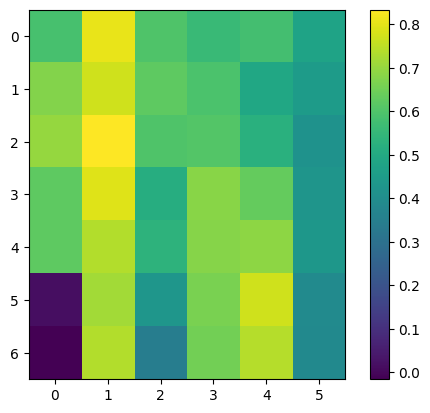

In [ ]:
print(days_look_backs1)
print(streangth_volis1)
print(days_max_to_sells1)

for sss in days_max_to_sells1:
  M = np.array([[sharp_ratios_bd_2[f"_{s}_{ss}_{sss}_bd"] for s in days_look_backs1] for ss in streangth_volis1])

  plt.imshow(M, interpolation='nearest')
  plt.colorbar()
  plt.show()

print("\n")


In [ ]:
[8, 1.5], [5, 1.3]

In [ ]:
#maximum_in_one_stock = [0]
days_look_backs2 = [5, 8]
streangth_volis2 = [1.3, 1.5]
days_max_to_sells2 = [3, 5, 7, 10, 12, 15, 17, 20, 22, 25, 27, 30]

print(len(days_look_backs2) * len(streangth_volis2) * len(days_max_to_sells2))
best_bd_hps2 = []
for i1 in days_look_backs2:
  for i2 in streangth_volis2:
    for i3 in days_max_to_sells2:
          best_bd_hps2.append([i1, i2, i3])

48


In [ ]:
sharp_ratios_bd_3 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_bd_hps2:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_moving_avarge_train_l = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_moving_avarge_train_l = buy_dip(finance_data_moving_avarge_train_l, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_3[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_3[combine_str]}")
  #for name in finance_names:
  #  finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


475
1109
508
1143
514
1083
479
1156
556
1268
487
1093
504
1172
params 5 1.3 3 checked _5_1.3_3_bd
			 0.08973272480311276 0.10685705734654734
	 sharp ratio portfolie: 0.8397454228231386
475
1167
508
1182
514
1114
479
1225
556
1314
487
1152
504
1219
params 5 1.3 5 checked _5_1.3_5_bd
			 0.08497774570187736 0.10253555225648225
	 sharp ratio portfolie: 0.828763719819972
475
1176
508
1190
514
1118
479
1237
556
1315
487
1159
504
1219
params 5 1.3 7 checked _5_1.3_7_bd
			 0.08424620370643039 0.10144789291049856
	 sharp ratio portfolie: 0.8304381815081738
475
1177
508
1190
514
1120
479
1237
556
1315
487
1159
504
1219
params 5 1.3 10 checked _5_1.3_10_bd
			 0.08521860374739636 0.10220487505973498
	 sharp ratio portfolie: 0.8338017506267604
475
1177
508
1190
514
1120
479
1237
556
1315
487
1159
504
1219
params 5 1.3 12 checked _5_1.3_12_bd
			 0.08521860374739636 0.10220487505973498
	 sharp ratio portfolie: 0.8338017506267604
475
1177
508
1190
514
1120
479
1237
556
1315
487
1159
504
1219
para

In [ ]:
sorted_d = dict(sorted(sharp_ratios_bd_3.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_5_1.3_3_bd 0.8397454228231386
_5_1.3_10_bd 0.8338017506267604
_5_1.3_12_bd 0.8338017506267604
_5_1.3_15_bd 0.8338017506267604
_5_1.3_17_bd 0.8338017506267604
_5_1.3_20_bd 0.8338017506267604
_5_1.3_22_bd 0.8338017506267604
_5_1.3_25_bd 0.8338017506267604
_5_1.3_27_bd 0.8338017506267604
_5_1.3_30_bd 0.8338017506267604
_5_1.3_7_bd 0.8304381815081738
_5_1.3_5_bd 0.828763719819972
_8_1.5_5_bd 0.8197190360208573
_8_1.5_10_bd 0.7775529723012852
_8_1.5_12_bd 0.7718441651335292
_8_1.5_15_bd 0.7718441651335292
_8_1.5_17_bd 0.7718441651335292
_8_1.5_20_bd 0.7718441651335292
_8_1.5_22_bd 0.7718441651335292
_8_1.5_25_bd 0.7718441651335292
_8_1.5_27_bd 0.7718441651335292
_8_1.5_30_bd 0.7718441651335292
_5_1.5_5_bd 0.7321397210071763
_8_1.5_7_bd 0.7240115550082011
_5_1.5_15_bd 0.7164655331886397
_5_1.5_17_bd 0.7164655331886397
_5_1.5_20_bd 0.7164655331886397
_5_1.5_22_bd 0.7164655331886397
_5_1.5_25_bd 0.7164655331886397
_5_1.5_27_bd 0.7164655331886397
_5_1.5_30_bd 0.7164655331886397
_5_1.5_12_bd 0.

In [ ]:
best_hyper_bd = [[8, 1.5, 5], [5, 1.3, 10]]

In [ ]:
sharp_ratios_bd_4 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_hyper_bd:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_moving_avarge_train_l = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_moving_avarge_train_l = buy_dip(finance_data_moving_avarge_train_l, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_4[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_4[combine_str]}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")
  print(finance_data_moving_avarge_train_l["portfolie_value" + combine_str].to_numpy())

654
1283
643
1291
662
1240
754
1496
751
1497
643
1261
684
1484
params 8 1.5 5 checked _8_1.5_5_bd
			 0.0485520875997946 0.09992965988219528
	 sharp ratio portfolie: 0.4858626323459072
			 0.004589470593657842 0.060178268366055235
	 sharp ratio gurkor: 0.07626458384845491
			 0.04358067156146227 0.25802558879584997
	 sharp ratio guitars: 0.16890057984110765
			 0.0073305814847995955 0.1822156220527036
	 sharp ratio slingshots: 0.04023025798896274
			 -0.03352769953301814 0.22941585897562275
	 sharp ratio stocks: -0.14614377437865236
			 -0.03853909185856976 0.22081987827031568
	 sharp ratio sugar: -0.17452727607879714
			 0.0003908010388156237 0.05217179594149531
	 sharp ratio water: 0.007490657198265941
			 0.02769424567970716 0.21208039603445383
	 sharp ratio tranquillity: 0.1305837135234699
[100.         100.         100.01173037 ... 286.50790857 286.52891368
 284.03091448]
821
1397
825
1393
849
1371
954
1580
932
1558
806
1357
866
1497
params 5 1.3 10 checked _5_1.3_10_bd
			 0.0602

Testa

In [ ]:
final_best_hyper_bd = [best_hyper_bd[1]]

In [ ]:
sharp_ratios_bd_v = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in final_best_hyper_bd:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_moving_avarge_train_l = test_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_moving_avarge_train_l = buy_dip(finance_data_moving_avarge_train_l, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_v[combine_str] = get_sharpe_ratio(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_v[combine_str]}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


107
252
125
280
112
248
113
277
114
263
117
267
130
326
params 5 1.3 10 checked _5_1.3_10_bd
			 0.16925152275754857 0.07400879531197231
	 sharp ratio portfolie: 2.2869109278714195
			 0.04184448838717983 0.03385819108972321
	 sharp ratio gurkor: 1.2358748958647308
			 0.06973638285858073 0.15747043234653427
	 sharp ratio guitars: 0.4428538222662443
			 0.12164994380886919 0.12864794610218608
	 sharp ratio slingshots: 0.9456034666285437
			 0.009015801877232926 0.1506833362748607
	 sharp ratio stocks: 0.05983277315274761
			 0.000990324262037463 0.17237132424153445
	 sharp ratio sugar: 0.005745295897650447
			 0.05096749162540108 0.049852045066019535
	 sharp ratio water: 1.0223751414391196
			 -0.013537293914709014 0.1766046392869272
	 sharp ratio tranquillity: -0.07665310475063541


# Plotar

107
252
125
280
112
248
113
277
114
263
117
267
130
326
params 5 1.3 10 checked _5_1.3_10_bd
			 0.16925152275754857 0.07400879531197231


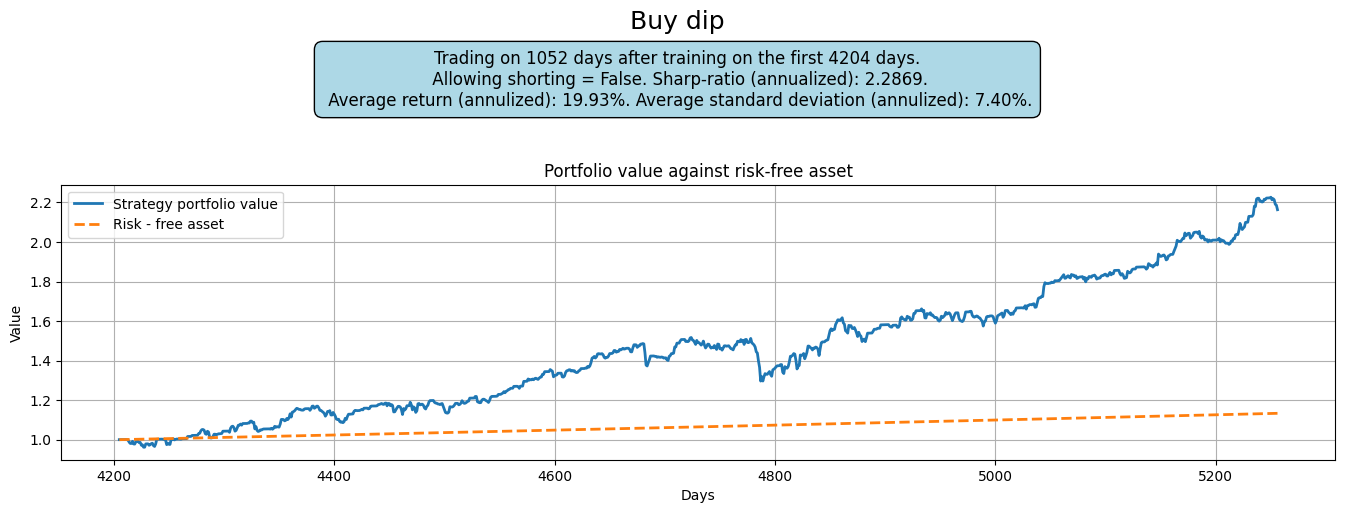

	 sharp ratio portfolie: 2.2869109278714195
			 0.04184448838717983 0.03385819108972321
	 sharp ratio gurkor: 1.2358748958647308
			 0.06973638285858073 0.15747043234653427
	 sharp ratio guitars: 0.4428538222662443
			 0.12164994380886919 0.12864794610218608
	 sharp ratio slingshots: 0.9456034666285437
			 0.009015801877232926 0.1506833362748607
	 sharp ratio stocks: 0.05983277315274761
			 0.000990324262037463 0.17237132424153445
	 sharp ratio sugar: 0.005745295897650447
			 0.05096749162540108 0.049852045066019535
	 sharp ratio water: 1.0223751414391196
			 -0.013537293914709014 0.1766046392869272
	 sharp ratio tranquillity: -0.07665310475063541
89
252
107
260
99
233
97
251
110
266
98
250
101
293
params 8 1.5 5 checked _8_1.5_5_bd
			 0.1607804752284989 0.10333259815316213


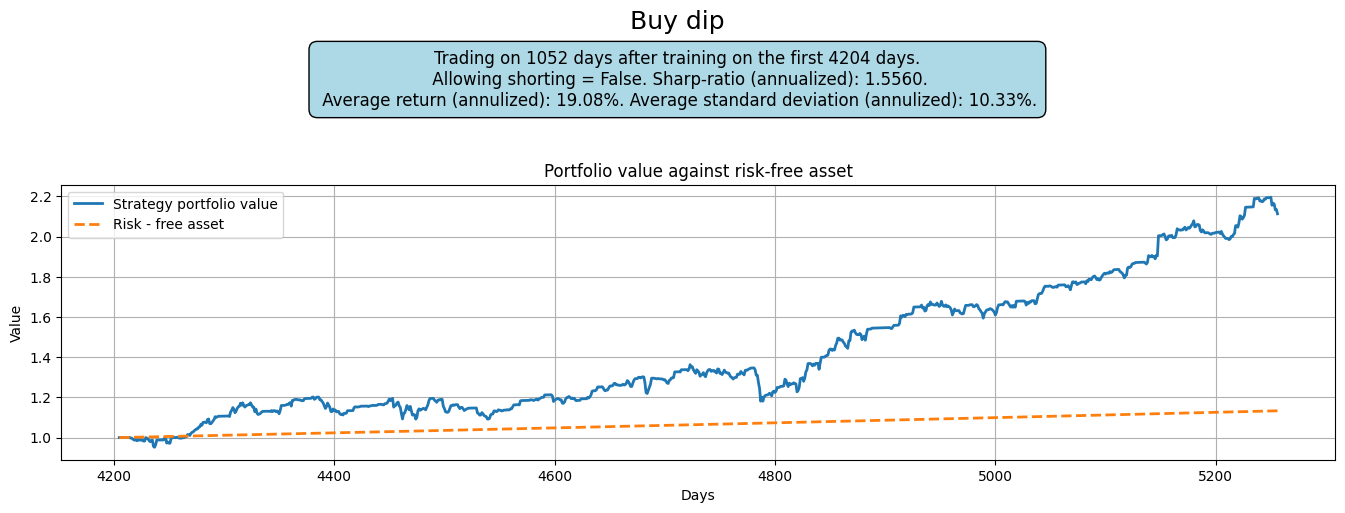

	 sharp ratio portfolie: 1.55595115289936
			 0.04192415588110347 0.03376877433278105
	 sharp ratio gurkor: 1.2415065903178366
			 0.06973809073363561 0.15748119176225767
	 sharp ratio guitars: 0.44283441059371775
			 0.12036947873773005 0.1254097108320301
	 sharp ratio slingshots: 0.9598098738856772
			 0.009958068300175253 0.15072378842885123
	 sharp ratio stocks: 0.06606832540489077
			 0.0020028891375958296 0.17253750216042998
	 sharp ratio sugar: 0.011608427805645926
			 0.051052021620000734 0.0498755546180594
	 sharp ratio water: 1.0235880485129554
			 -0.015415859116222114 0.17228052311953873
	 sharp ratio tranquillity: -0.08948114875136322


In [92]:
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in [[5, 1.3, 10], [8, 1.5, 5]]: #8, 1.5, 5
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_moving_avarge_train_l = test_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_moving_avarge_train_l = buy_dip(finance_data_moving_avarge_train_l, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_moving_avarge_train_l = stocks_positions(finance_data_moving_avarge_train_l, finance_names, combine_str)

  finance_data_moving_avarge_train_l = several_stock_trade(finance_data_moving_avarge_train_l, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_moving_avarge_train_l, 252, combine_str = combine_str)
  plot_time_series(finance_data_moving_avarge_train_l['day'].to_numpy(), finance_data_moving_avarge_train_l["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_bd2 , mean_v , std_v, "Buy dip")

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd2}")
  for name in finance_names:
    finance_data_moving_avarge_train_l = one_stock_trade(finance_data_moving_avarge_train_l, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_moving_avarge_train_l, name, 252, combine_str = combine_str)}")


#old code

In [ ]:
print(finance_data)
print(finance_names)

      Unnamed: 0   day    gurkor   guitars  slingshots     stocks     sugar  \
0              0     1  6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2  6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3  6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4  6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5  6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...       ...       ...         ...        ...       ...   
5451        5451  5452       NaN       NaN         NaN        NaN       NaN   
5452        5452  5453       NaN       NaN         NaN        NaN       NaN   
5453        5453  5454       NaN       NaN         NaN        NaN       NaN   
5454        5454  5455       NaN       NaN         NaN        NaN       NaN   
5455        5455  5456       NaN       NaN         NaN        NaN       NaN   

         water  tranquillity  
0     3.896149      

In [ ]:
for name in finance_names:
  finance_data = remove_1000(finance_data, name)

[ 6.31581555  6.825179    9.27880519  9.05006504 11.37014512] [ 6.26452498  6.85266821  9.181506    9.04200502 11.46444389]
[2.83043642 5.74900107 4.85888389 6.81445677 5.05114593] [2.85406559 5.41987344 4.85304529 6.82222064 4.90162681]
[2.05786636 3.39560267 3.81753475 4.92829802 3.06994825] [2.07016982 3.44239554 3.88330984 4.92515297 3.00913931]
[9.10307757 8.68991977 6.27277201 5.13249983 4.63075894] [8.83745388 8.8367195  6.20489274 5.0972318  4.54038977]
[3.57234686 3.39488235 2.07917243 3.30055146 1.760932  ] [3.64148906 3.23149229 2.07161867 3.30825403 1.72400296]
[3.97410653 4.69767736 5.89565424 6.21961548 6.6929798 ] [3.99621039 4.704141   5.88280296 6.20774392 6.7114342 ]
[ 7.46344565 10.34647171 10.41322314 18.65861411 10.20343293] [ 7.40623013 10.29561348 10.40686586 19.16719644  9.89192626]


In [ ]:
periods = [[4, 15],
           [7, 25],
           [14, 50],
           [25, 100],
           [50, 200]]

In [ ]:
finance_data_buy = finance_data.copy()

for i, name in enumerate(finance_names):
  for short_window, long_window in periods:
    finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window, long_window)
  #finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window = 4, long_window = 15)
  #finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window = 7, long_window = 25)
  #finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window = 14, long_window = 50)
  #finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window = 25, long_window = 100)
  #finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window = 50, long_window = 200)


In [ ]:
params_grid = []
count = 0
for k in [50]:#[1, 5, 10]:
  for d in [2]:#[1, 2, 3]:
    for x in [0.005, 0.05]:#[0.001, 0.005, 0.01, 0.05]:
      for c in [0.01, 0.05]:#[0.005, 0.01, 0.05, 0.1]:
        for j in [5, 8]:#, 20, 25]:
          params_grid.append([k, d, x, c, j])
          count += 1
print(count)

8


In [ ]:

for i in range(len(params_grid)):
  for j, name in enumerate(finance_names):

    print(i)
    print(params_grid[i])
    combine_str = "_" + "_".join([str(j) for j in params_grid[i]])
    finance_data_buy = channal_breakout(finance_data_buy, name, x = params_grid[i][2], d = params_grid[i][1], j = params_grid[i][4], c = params_grid[i][3], k = params_grid[i][0], combine_str=combine_str)

0
[50, 2, 0.005, 0.01, 5]
793 897
0
[50, 2, 0.005, 0.01, 5]
1232 1400
0
[50, 2, 0.005, 0.01, 5]
1287 1309
0
[50, 2, 0.005, 0.01, 5]
776 612
0
[50, 2, 0.005, 0.01, 5]
1397 1154
0
[50, 2, 0.005, 0.01, 5]
685 592
0
[50, 2, 0.005, 0.01, 5]
1094 2267
1
[50, 2, 0.005, 0.01, 8]
495 669
1
[50, 2, 0.005, 0.01, 8]
395 280
1
[50, 2, 0.005, 0.01, 8]
219 372
1
[50, 2, 0.005, 0.01, 8]
51 0
1
[50, 2, 0.005, 0.01, 8]
51 153
1
[50, 2, 0.005, 0.01, 8]
587 732
1
[50, 2, 0.005, 0.01, 8]
436 282
2
[50, 2, 0.005, 0.05, 5]
0 0
2
[50, 2, 0.005, 0.05, 5]
1189 1387
2
[50, 2, 0.005, 0.05, 5]
1154 1028
2
[50, 2, 0.005, 0.05, 5]
1520 2565
2
[50, 2, 0.005, 0.05, 5]
1200 1642
2
[50, 2, 0.005, 0.05, 5]
0 0
2
[50, 2, 0.005, 0.05, 5]
891 1452
3
[50, 2, 0.005, 0.05, 8]
0 0
3
[50, 2, 0.005, 0.05, 8]
1045 1711
3
[50, 2, 0.005, 0.05, 8]
988 1625
3
[50, 2, 0.005, 0.05, 8]
1899 2509
3
[50, 2, 0.005, 0.05, 8]
1433 2066
3
[50, 2, 0.005, 0.05, 8]
0 0
3
[50, 2, 0.005, 0.05, 8]
942 1658
4
[50, 2, 0.05, 0.01, 5]
0 0
4
[50, 2, 0.05

In [ ]:
print(finance_data_buy)

      Unnamed: 0   day    gurkor   guitars  slingshots     stocks     sugar  \
0              0     1  6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2  6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3  6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4  6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5  6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...       ...       ...         ...        ...       ...   
5451        5451  5452       NaN       NaN         NaN        NaN       NaN   
5452        5452  5453       NaN       NaN         NaN        NaN       NaN   
5453        5453  5454       NaN       NaN         NaN        NaN       NaN   
5454        5454  5455       NaN       NaN         NaN        NaN       NaN   
5455        5455  5456       NaN       NaN         NaN        NaN       NaN   

         water  tranquillity  gurkor_signal_4_15  .

In [ ]:
for short_window, long_window in periods:
  long_window_text = "_" + str(long_window)
  short_window_text = "_" + str(short_window)
  combine_str = short_window_text + long_window_text
  finance_data_buy = get_return_portfolie(finance_data_buy, finance_names, combine_str = combine_str)
  print(f"short window {short_window}, long window {long_window} checked")

short window 4, long window 15 checked
short window 7, long window 25 checked
short window 14, long window 50 checked
short window 25, long window 100 checked
short window 50, long window 200 checked


In [ ]:
for i in range(len(params_grid)):
    print(i)
    print(params_grid[i])
    combine_str = "_" + "_".join([str(j) for j in params_grid[i]])
    finance_data_buy = get_return_portfolie(finance_data_buy, finance_names, False, combine_str= combine_str, lend_possible = True)
    print(combine_str," checked")

0
[50, 2, 0.005, 0.01, 5]
_50_2_0.005_0.01_5  checked
1
[50, 2, 0.005, 0.01, 8]
_50_2_0.005_0.01_8  checked
2
[50, 2, 0.005, 0.05, 5]
_50_2_0.005_0.05_5  checked
3
[50, 2, 0.005, 0.05, 8]
_50_2_0.005_0.05_8  checked
4
[50, 2, 0.05, 0.01, 5]
_50_2_0.05_0.01_5  checked
5
[50, 2, 0.05, 0.01, 8]
_50_2_0.05_0.01_8  checked
6
[50, 2, 0.05, 0.05, 5]


/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name + "_change" + combine_str] = df[name]/df[name].shift(1)
/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name + "_change" + combine_str] = df[name]/df[name].shift(1)
/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axi

_50_2_0.05_0.05_5  checked
7
[50, 2, 0.05, 0.05, 8]


/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name + "_change" + combine_str] = df[name]/df[name].shift(1)
/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name + "_change" + combine_str] = df[name]/df[name].shift(1)
/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axi

_50_2_0.05_0.05_8  checked


In [ ]:
sharp_ratios_2 = {}
for averaging_time in [1, 5, 21, 63, 252]:
  print(f"Averaging time: {averaging_time}\n\t\tshort,  long,   sharpratio")
  for i in range(len(params_grid)):
    print(i)
    combine_str = "_" + "_".join([str(j) for j in params_grid[i]])
    print(combine_str," checked")
    sharp_ratios_2[combine_str] = get_sharpe_ratio(finance_data_buy, finance_names, averaging_time, combine_str = combine_str)
    print(f"\t\t "+combine_str+f": \t{sharp_ratios_2[combine_str]:4f}")
print("\n", sharp_ratios_2)

Averaging time: 1
		short,  long,   sharpratio
0
_50_2_0.005_0.01_5  checked
247 5256
1.0002320062660313 0.00827811433947272
		 _50_2_0.005_0.01_5: 	0.013856
1
_50_2_0.005_0.01_8  checked
247 5256
1.0001404505415228 0.004309093255922443
		 _50_2_0.005_0.01_8: 	0.005372
2
_50_2_0.005_0.05_5  checked
247 5256
0.9999638897836165 0.011818216018397007
		 _50_2_0.005_0.05_5: 	-0.012981
3
_50_2_0.005_0.05_8  checked
247 5256
1.0001342050049762 0.01072560718934694
		 _50_2_0.005_0.05_8: 	0.001576
4
_50_2_0.05_0.01_5  checked
247 5256
1.0001173037138344 1.354472090042691e-14
		 _50_2_0.05_0.01_5: 	 nan
5
_50_2_0.05_0.01_8  checked
247 5256
1.0001173037138344 1.354472090042691e-14
		 _50_2_0.05_0.01_8: 	 nan
6
_50_2_0.05_0.05_5  checked
247 5256
1.0001173037138344 1.354472090042691e-14
		 _50_2_0.05_0.05_5: 	 nan
7
_50_2_0.05_0.05_8  checked
247 5256
1.0001173037138344 1.354472090042691e-14
		 _50_2_0.05_0.05_8: 	 nan
Averaging time: 5
		short,  long,   sharpratio
0
_50_2_0.005_0.01_5  checked
2

/tmp/ipykernel_2727/2382786547.py:112: RuntimeWarning: invalid value encountered in scalar divide
  return np.mean(returns - cost_rent) / np.std(returns - cost_rent)


247 5256
0.9998096237964129 0.02572763954498904
		 _50_2_0.005_0.05_5: 	-0.030202
3
_50_2_0.005_0.05_8  checked
247 5256
1.0006613259670891 0.024200740341866055
		 _50_2_0.005_0.05_8: 	0.003085
4
_50_2_0.05_0.01_5  checked
247 5256
1.0005866561869274 2.5757174171303632e-14
		 _50_2_0.05_0.01_5: 	-inf
5
_50_2_0.05_0.01_8  checked
247 5256
1.0005866561869274 2.5757174171303632e-14
		 _50_2_0.05_0.01_8: 	-inf
6
_50_2_0.05_0.05_5  checked
247 5256
1.0005866561869274 2.5757174171303632e-14
		 _50_2_0.05_0.05_5: 	-inf
7
_50_2_0.05_0.05_8  checked
247 5256


/tmp/ipykernel_2727/2382786547.py:112: RuntimeWarning: divide by zero encountered in scalar divide
  return np.mean(returns - cost_rent) / np.std(returns - cost_rent)


1.0005866561869274 2.5757174171303632e-14
		 _50_2_0.05_0.05_8: 	-inf
Averaging time: 21
		short,  long,   sharpratio
0
_50_2_0.005_0.01_5  checked
247 5256
1.0048432047051248 0.03666374314495092
		 _50_2_0.005_0.01_5: 	0.064831
1
_50_2_0.005_0.01_8  checked
247 5256
1.0028279741965007 0.022360762534957977
		 _50_2_0.005_0.01_8: 	0.016176
2
_50_2_0.005_0.05_5  checked
247 5256
0.9987240467673694 0.05303055550421627
		 _50_2_0.005_0.05_5: 	-0.070567
3
_50_2_0.005_0.05_8  checked
247 5256
1.0021942315002283 0.04962808717764808
		 _50_2_0.005_0.05_8: 	-0.005482
4
_50_2_0.05_0.01_5  checked
247 5256
1.0024662697723024 8.659739592076221e-14
		 _50_2_0.05_0.01_5: 	-inf
5
_50_2_0.05_0.01_8  checked
247 5256
1.0024662697723024 8.659739592076221e-14
		 _50_2_0.05_0.01_8: 	-inf
6
_50_2_0.05_0.05_5  checked
247 5256
1.0024662697723024 8.659739592076221e-14
		 _50_2_0.05_0.05_5: 	-inf
7
_50_2_0.05_0.05_8  checked
247 5256
1.0024662697723024 8.659739592076221e-14
		 _50_2_0.05_0.05_8: 	-inf
Averagi

In [ ]:
print(finance_data_buy)

      Unnamed: 0   day    gurkor   guitars  slingshots     stocks     sugar  \
0              0     1  6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2  6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3  6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4  6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5  6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...       ...       ...         ...        ...       ...   
5451        5451  5452       NaN       NaN         NaN        NaN       NaN   
5452        5452  5453       NaN       NaN         NaN        NaN       NaN   
5453        5453  5454       NaN       NaN         NaN        NaN       NaN   
5454        5454  5455       NaN       NaN         NaN        NaN       NaN   
5455        5455  5456       NaN       NaN         NaN        NaN       NaN   

         water  tranquillity  gurkor_signal_4_15  .

In [ ]:
finance_data_buy = get_return_portfolie_buy_and_hold(finance_data_buy, finance_names, weighting="active")

In [ ]:
for averaging_time in [1, 5, 21, 63, 252]:
  print(finance_data_buy.keys()[2:].to_list())
  print(get_sharpe_ratio(finance_data_buy, finance_names, averaging_time, combine_str = "_buy_and_hold"))

['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity', 'gurkor_signal_4_15', 'gurkor_signal_7_25', 'gurkor_signal_14_50', 'gurkor_signal_25_100', 'gurkor_signal_50_200', 'guitars_signal_4_15', 'guitars_signal_7_25', 'guitars_signal_14_50', 'guitars_signal_25_100', 'guitars_signal_50_200', 'slingshots_signal_4_15', 'slingshots_signal_7_25', 'slingshots_signal_14_50', 'slingshots_signal_25_100', 'slingshots_signal_50_200', 'stocks_signal_4_15', 'stocks_signal_7_25', 'stocks_signal_14_50', 'stocks_signal_25_100', 'stocks_signal_50_200', 'sugar_signal_4_15', 'sugar_signal_7_25', 'sugar_signal_14_50', 'sugar_signal_25_100', 'sugar_signal_50_200', 'water_signal_4_15', 'water_signal_7_25', 'water_signal_14_50', 'water_signal_25_100', 'water_signal_50_200', 'tranquillity_signal_4_15', 'tranquillity_signal_7_25', 'tranquillity_signal_14_50', 'tranquillity_signal_25_100', 'tranquillity_signal_50_200', 'gurkor_change_4_15', 'guitars_change_4_15', 'slingshots_change_4_15',

In [ ]:
finance_data_buy = get_return_portfolie_buy_and_hold(finance_data_buy, finance_names, weighting="equal")

In [ ]:
print(finance_data_buy)

      Unnamed: 0   day    gurkor   guitars  slingshots     stocks     sugar  \
0              0     1  6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2  6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3  6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4  6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5  6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...       ...       ...         ...        ...       ...   
5451        5451  5452       NaN       NaN         NaN        NaN       NaN   
5452        5452  5453       NaN       NaN         NaN        NaN       NaN   
5453        5453  5454       NaN       NaN         NaN        NaN       NaN   
5454        5454  5455       NaN       NaN         NaN        NaN       NaN   
5455        5455  5456       NaN       NaN         NaN        NaN       NaN   

         water  tranquillity  gurkor_signal_4_15  .

In [ ]:
for averaging_time in [1, 5, 21, 63, 252]:
  print(finance_data_buy.keys()[2:].to_list())
  print(get_sharpe_ratio(finance_data_buy, finance_names, averaging_time, combine_str = "_buy_and_hold"))

['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity', 'gurkor_signal_4_15', 'gurkor_signal_7_25', 'gurkor_signal_14_50', 'gurkor_signal_25_100', 'gurkor_signal_50_200', 'guitars_signal_4_15', 'guitars_signal_7_25', 'guitars_signal_14_50', 'guitars_signal_25_100', 'guitars_signal_50_200', 'slingshots_signal_4_15', 'slingshots_signal_7_25', 'slingshots_signal_14_50', 'slingshots_signal_25_100', 'slingshots_signal_50_200', 'stocks_signal_4_15', 'stocks_signal_7_25', 'stocks_signal_14_50', 'stocks_signal_25_100', 'stocks_signal_50_200', 'sugar_signal_4_15', 'sugar_signal_7_25', 'sugar_signal_14_50', 'sugar_signal_25_100', 'sugar_signal_50_200', 'water_signal_4_15', 'water_signal_7_25', 'water_signal_14_50', 'water_signal_25_100', 'water_signal_50_200', 'tranquillity_signal_4_15', 'tranquillity_signal_7_25', 'tranquillity_signal_14_50', 'tranquillity_signal_25_100', 'tranquillity_signal_50_200', 'gurkor_change_4_15', 'guitars_change_4_15', 'slingshots_change_4_15',

In [ ]:
sharp_ratios = {}
for averaging_time in [1, 5, 21, 63, 252]:
  print(f"Averaging time: {averaging_time}\n\t\tshort,  long,   sharpratio")
  for short_window, long_window in periods:
    sharp_ratios[str(averaging_time) + f"_{short_window}_{long_window}"] = get_sharpe_ratio(finance_data_buy, finance_names, averaging_time, short_window=short_window, long_window = long_window)
    print(f"\t\t{short_window}, \t{long_window}: \t{sharp_ratios[str(averaging_time) + f"_{short_window}_{long_window}"]:4f}")
print("\n", sharp_ratios)

Averaging time: 1
		short,  long,   sharpratio
247 5256
247          NaN
248          NaN
249     0.993350
250     0.999181
251     0.997611
          ...   
5251    1.003575
5252    0.992058
5253    1.006518
5254    0.993149
5255    1.004019
Name: total_return_per_day_4_15, Length: 5009, dtype: float64
1.0000983376617676 0.006851374711672563
		4, 	15: 	-0.002768
247 5256
247          NaN
248          NaN
249     0.993350
250     0.999181
251     1.000640
          ...   
5251    1.006765
5252    0.992995
5253    0.992073
5254    0.994029
5255    0.996857
Name: total_return_per_day_7_25, Length: 5009, dtype: float64
1.000207390201076 0.006774786398690723
		7, 	25: 	0.013297
247 5256
247          NaN
248          NaN
249     0.995306
250     0.999534
251     1.002426
          ...   
5251    1.006765
5252    0.992995
5253    0.992073
5254    0.994029
5255    0.989631
Name: total_return_per_day_14_50, Length: 5009, dtype: float64
1.0002935652402452 0.006276966364460393
		14, 	50: 	0.0280

In [ ]:
print(get_sharpe_ratio(finance_data_buy, finance_names, short_window=14, long_window = 50))
print(get_sharpe_ratio(finance_data_buy, finance_names, short_window=25, long_window=100))
print(get_sharpe_ratio(finance_data_buy, finance_names, short_window=50, long_window=200))

247 5256
247          NaN
248          NaN
249     0.995306
250     0.999534
251     1.002426
          ...   
5251    1.006765
5252    0.992995
5253    0.992073
5254    0.994029
5255    0.989631
Name: total_return_per_day_14_50, Length: 5009, dtype: float64
1.0058757675172763 0.02779391412431211
0.12267065839388956
247 5256
247          NaN
248          NaN
249     0.993088
250     0.996686
251     1.003033
          ...   
5251    1.002469
5252    0.995013
5253    0.995096
5254    0.995570
5255    0.993239
Name: total_return_per_day_25_100, Length: 5009, dtype: float64
1.0057501039257424 0.029681498991708244
0.11063572477778248
247 5256
247          NaN
248          NaN
249     0.993262
250     0.995719
251     1.005293
          ...   
5251    1.002469
5252    0.995013
5253    0.995096
5254    0.995570
5255    0.993239
Name: total_return_per_day_50_200, Length: 5009, dtype: float64
1.0045568028507206 0.029393679939237083
0.07112185622005386


In [ ]:
print(get_sharpe_ratio(finance_data_buy, finance_names, 252, short_window=14, long_window = 50))
print(get_sharpe_ratio(finance_data_buy, finance_names, 252, short_window=25, long_window=100))
print(get_sharpe_ratio(finance_data_buy, finance_names, 252, short_window=50, long_window=200))

247 5256
247          NaN
248          NaN
249     0.995306
250     0.999534
251     1.002426
          ...   
5251    1.006765
5252    0.992995
5253    0.992073
5254    0.994029
5255    0.989631
Name: total_return_per_day_14_50, Length: 5009, dtype: float64
1.0661574633935589 0.09422964602613895
0.38371643021484864
247 5256
247          NaN
248          NaN
249     0.993088
250     0.996686
251     1.003033
          ...   
5251    1.002469
5252    0.995013
5253    0.995096
5254    0.995570
5255    0.993239
Name: total_return_per_day_25_100, Length: 5009, dtype: float64
1.0599607436889489 0.10954322563331934
0.27350612980156425
247 5256
247          NaN
248          NaN
249     0.993262
250     0.995719
251     1.005293
          ...   
5251    1.002469
5252    0.995013
5253    0.995096
5254    0.995570
5255    0.993239
Name: total_return_per_day_50_200, Length: 5009, dtype: float64
1.043082803417262 0.09782947483359708
0.13373069250872666


# Extra

In [ ]:
import torch
from torch import nn, optim
from torch.amp import GradScaler, autocast
import torch.nn.functional as F

In [ ]:
torch.backends.cudnn.benchmark = True

torch.backends.cudnn.deterministic = False

torch.set_default_dtype(torch.float32)

print(f"Using device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"cudnn.benchmark enabled: {torch.backends.cudnn.benchmark}")

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


Using device: cpu
cudnn.benchmark enabled: True


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


In [ ]:
class LSTM6(nn.Module):
    def __init__(self, input_size=2, size_hidden=8, num_layers=3,
                 dropout_layers_lstm=0.2, dropout_out=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=size_hidden,
            num_layers=num_layers,
            dropout=dropout_layers_lstm if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.eps = 1e-7
        self.norm = nn.LayerNorm(size_hidden, eps=self.eps)
        self.fc = nn.Linear(size_hidden, 1)
        self.dropout = nn.Dropout(dropout_out)

        self.num_layers = num_layers
        self.size_hidden = size_hidden
        self.hidden_state = None

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and len(param.shape) > 1:
                if 'lstm' in name:
                    nn.init.xavier_uniform_(param)
                elif 'fc' in name:
                    nn.init.xavier_uniform_(param, gain=0.1)
            elif 'bias' in name:
                nn.init.zeros_(param)

    def forward(self, x):
        # Safety check for NaN inputs
        if torch.isnan(x).any():
            print("Warning: NaN in input!")
            return torch.zeros(x.size(0), 1, device=x.device)

        x = torch.clamp(x, min=-10, max=10)

        if self.hidden_state is None:
            self.hidden_state = self.init_hidden(x.size(0), x.device)
        else:
            h, c = self.hidden_state
            if h.size(1) != x.size(0):
                self.hidden_state = self.init_hidden(x.size(0), x.device)

        out, hidden_new = self.lstm(x, self.hidden_state)
        out = torch.clamp(out, min=-100, max=100)

        out = self.norm(out)
        out = out[:, -1, :]

        out = self.dropout(out)
        out = self.fc(out)

        out = torch.clamp(out, min=-50, max=50)
        self.hidden_state = (hidden_new[0].detach(), hidden_new[1].detach())

        return out

    def init_hidden(self, batch_size, device=None):
        if device is None:
            device = next(self.parameters()).device

        h0 = torch.randn(self.num_layers, batch_size, self.size_hidden, device=device) * 0.01
        c0 = torch.randn(self.num_layers, batch_size, self.size_hidden, device=device) * 0.01

        self.hidden_state = (h0, c0)
        return (h0, c0)

    def reset_hidden(self):
        self.hidden_state = None

In [ ]:
def make_windows(data_x, labels_y, seq_len, delta_init=0):
    T = data_x.shape[0]
    if T < seq_len + delta_init:
        raise ValueError("I think")
    starts = torch.arange(delta_init, T - seq_len + 1)
    x_windows = torch.stack([data_x[i:i + seq_len] for i in starts])
    y_windows = torch.stack([labels_y[i + seq_len - 1] for i in starts]) # minus one for correctness
    return x_windows, y_windows


In [ ]:
import copy

In [ ]:
def train_model(model, data_x, data_y, data_x_val, data_y_val, freq, num_epochs=100, learning_rate=1e-4, seq_len=5, warmup_days=10, decay=0.01):
    model.to(device)

    all_windows_x = []
    all_windows_y = []
    for stock in range(len(data_x)):
        window_x, window_y = make_windows(data_x[stock], data_y[stock], seq_len)
        if len(window_x) > warmup_days:
            all_windows_x.append(window_x.to(device, non_blocking=True))
            all_windows_y.append(window_y.to(device, non_blocking=True).float())

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=decay)
    scaler = GradScaler()
    pos_weight = torch.tensor([(1 - freq) / freq], dtype=torch.float32, device=device)

    best_val_loss = float('inf')
    best_model = None

    for epoch in range(num_epochs):
        model.train()

        stock_order = torch.randperm(len(all_windows_x), device=device)

        epoch_loss = 0.0
        epoch_samples = 0

        for stock_pos in range(len(stock_order)):
            stock_idx = stock_order[stock_pos].item()

            window_x = all_windows_x[stock_idx]
            window_y = all_windows_y[stock_idx]

            model.reset_hidden()

            with torch.no_grad():
                for i in range(0, warmup_days, 16):
                    batch_end = min(i + 16, warmup_days)
                    _ = model(window_x[i:batch_end])

            logits = torch.empty(len(window_x)-warmup_days, device=device)
            targets = window_y[warmup_days:]

            pos = 0
            batch_size = 32
            for i in range(warmup_days, len(window_x), batch_size):
                batch_end = min(i + batch_size, len(window_x))
                data = window_x[i:batch_end]

                with autocast(device_type='cuda'):
                    batch_logits = model(data).squeeze(1)

                batch_len = batch_logits.shape[0]
                logits[pos:pos + batch_len] = batch_logits
                pos += batch_len

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type='cuda'):
                loss = F.binary_cross_entropy_with_logits(
                    logits,
                    targets,
                    pos_weight=pos_weight,
                    reduction='mean'
                )

            scaler.scale(loss).backward()

            epoch_loss += loss.item() * logits.shape[0]
            epoch_samples += logits.shape[0]

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

            scaler.step(optimizer)
            scaler.update()


            if (stock_pos + 1) % 10 == 0:
                print(f"\t\tStock {stock_pos + 1}/{len(all_windows_x)}")

        avg_epoch_loss = epoch_loss / epoch_samples

        val_loss = evaluate_model(model, data_x_val, data_y_val, freq, seq_len, warmup_days)
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_epoch_loss:.4}, Val Loss: {val_loss:.4}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())

    if best_model is not None:
        model.load_state_dict(best_model)

    return model


def evaluate_model(model, data_x_val, data_y_val, freq, seq_len, warmup_days):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    pos_weight = torch.tensor([(1 - freq) / freq], dtype=torch.float32, device=device)

    with torch.no_grad():
        for stock_idx in range(len(data_x_val)):
            window_x, window_y = make_windows(data_x_val[stock_idx], data_y_val[stock_idx], seq_len)

            if len(window_x) <= warmup_days:
                continue
            window_x = window_x.to(device, non_blocking=True)
            window_y = window_y.to(device, non_blocking=True).float()

            model.reset_hidden()

            # Warmup
            for i in range(0, warmup_days, 32):
                batch_end = min(i + 32, warmup_days)
                _ = model(window_x[i:batch_end])

            batch_size = 64
            for i in range(warmup_days, len(window_x), batch_size):
                batch_end = min(i + batch_size, len(window_x))

                logits = model(window_x[i:batch_end])
                logits = logits.squeeze(1)

                loss = F.binary_cross_entropy_with_logits(
                    logits, window_y[i:batch_end],
                    pos_weight=pos_weight,
                    reduction='sum'
                )

                total_loss += loss.item()
                total_samples += (batch_end - i)

    return total_loss / total_samples if total_samples > 0 else float('inf')

In [ ]:
def predict_avg_return_on_investment(model, stock_params_normilized, stock_params_non_normilized, threshold=0.5, batch_size=1, seq_len=10):
  predictions = np.zeros(stock_params_non_normilized.size(0) - 11)
  model.eval()
  with torch.no_grad():
            window_x, window_y = make_windows(stock_params_normilized, torch.zeros(stock_params_normilized.size(0)), seq_len, delta_init=0)
            window_x = window_x.to(device, non_blocking=True)
            window_y = window_y.to(device, non_blocking=True).float()
            model.eval()
            model.reset_hidden()

            for i in range(0, 10, 10):
                _ = model(window_x[0:10])

            batch_size = 32  # Large batch for evaluation
            for i in range(0, len(window_x), batch_size):
                batch_end = min(10+ i + batch_size, len(window_x)-1)

                logits = model(window_x[10+i:batch_end])
                logits = logits.squeeze(1)

                predictions[i:batch_end-10] = logits.cpu().numpy().reshape(-1,)
  return_on_investment = ((stock_params_non_normilized[11:,0])/(stock_params_non_normilized[10:-1,0]) - 1).numpy()

  decisions = (1/(1+np.exp(-predictions)) > threshold).astype(int)
  profit_sum = np.sum(return_on_investment[decisions == 1])
  returns =  np.where(decisions == 1, return_on_investment, 1.03**(1/252))
  return profit_sum, np.shape(return_on_investment[decisions == 1])[0], returns

In [ ]:

def combine_params(json_data, stock_name, stock_name2, after_split=0):
    adj_close = json_data.get(stock_name).to_numpy()
    target = json_data.get(stock_name + "_t").to_numpy()
    adj_close2 = json_data.get(stock_name2).to_numpy()
    target2 = json_data.get(stock_name2 + "_t").to_numpy()

    nan_idx = np.where(np.isnan(adj_close))[0]
    nan_idx_t = np.where(np.isnan(target))[0]
    nan_idx_2 = np.where(np.isnan(adj_close))[0]
    nan_idx_t_2 = np.where(np.isnan(target))[0]

    nan_idx = np.concatenate((nan_idx, nan_idx_t))
    nan_idx = np.unique(nan_idx)

    if len(nan_idx) == 0 and len(nan_idx_2) == 0:
      pass
    elif len(nan_idx) == 0:
      i2_min = min(nan_idx_2)
      i2_max = max(nan_idx_2)
      intervalls = [[0, i2_min], [(i2_max + 1), len(adj_close)]]
      adj_close = adj_close[intervalls[after_split][0]:intervalls[after_split][1]]
      target = target[intervalls[after_split][0]:intervalls[after_split][1]]
      adj_close2 = adj_close2[intervalls[after_split][0]:intervalls[after_split][1]]
      target2 = target2[intervalls[after_split][0]:intervalls[after_split][1]]
    elif len(nan_idx_2) == 0:
      i1_min = min(nan_idx)
      i1_max = max(nan_idx)
      intervalls = [[0, i1_min], [(i1_max + 1) , len(adj_close)]]
      adj_close = adj_close[intervalls[after_split][0]:intervalls[after_split][1]]
      target = target[intervalls[after_split][0]:intervalls[after_split][1]]
      adj_close2 = adj_close2[intervalls[after_split][0]:intervalls[after_split][1]]
      target2 = target2[intervalls[after_split][0]:intervalls[after_split][1]]
    else:
      i1_min = min(nan_idx)
      i1_max = max(nan_idx)

      i2_min = min(nan_idx_2)
      i2_max = max(nan_idx_2)
      if i1_min > i2_min:
          i1_min, i2_min = i2_min, i1_min
          i1_max, i2_max = i2_max, i1_max

      l0 = i1_min - 0
      l1 = i2_min - (i1_max + 1)
      l2 = len(adj_close) - (i2_max + 1)
      m = min(l0, l1, l2)
      if l0 == m:
        intervalls = [[(i1_max + 1), i2_min], [(i2_max + 1) , len(adj_close)]]
      elif l1 == m:
        intervalls = [[0, i1_min], [(i2_max + 1) , len(adj_close)]]
      else:
        intervalls = [[i1_min, (i1_max + 1)], [0, i1_min]]
      adj_close = adj_close[intervalls[after_split][0]:intervalls[after_split][1]]
      target = target[intervalls[after_split][0]:intervalls[after_split][1]]
      adj_close2 = adj_close2[intervalls[after_split][0]:intervalls[after_split][1]]
      target2 = target2[intervalls[after_split][0]:intervalls[after_split][1]]

    size_volume = len(adj_close)
    x_data = np.zeros((size_volume, 2), dtype=np.float64)
    y_data = np.zeros(size_volume, dtype=np.int64)
    x_data[:, 0] = np.array(adj_close)
    x_data[:, 1] = np.array(adj_close2)

    y_data = np.where((target > 1.005) & (target > target2), 1, 0).astype(int)
    print(y_data.shape, x_data.shape)
    print("\t", stock_name, x_data.shape, y_data.shape, y_data.sum())
    return x_data, y_data


In [ ]:
def normalize_one_stock(price_volume, lookback_days=20):

    n_days = price_volume.shape[0] - 1
    normalized = torch.zeros_like(price_volume[:-1])

    for today in range(n_days):
            normalized[today, 0] = price_volume[max(today, 1), 0]/(price_volume[max(today-1, 0), 0] + 1e-8) - 1
    return normalized

In [ ]:
for name in finance_names:
  finance_data[name+"_t"] = (finance_data[name].shift(-1) / finance_data[name] ).astype(float)
training_data, test_data =  training_test_split(finance_data, part_slit=0.8)
training_data, valid_data =  training_test_split(training_data, part_slit=0.8)

Index([1398, 1399, 1400, 1401, 1402, 1403, 1404, 1405, 1406, 1407,
       ...
       5446, 5447, 5448, 5449, 5450, 5451, 5452, 5453, 5454, 5455],
      dtype='int64', length=250)
0 5255
Index([1398, 1399, 1400, 1401, 1402, 1403, 1404, 1405, 1406, 1407, 1408, 1409,
       1410, 1411, 1412, 1413, 1414, 1415, 1416, 1417, 1418, 1419, 1420, 1421,
       1422, 1423, 1424, 1425, 1426, 1427, 1428, 1429, 1430, 1431, 1432, 1433,
       1434, 1435, 1436, 1437, 1438, 1439, 1440, 1441, 1442, 1443, 1444, 1445,
       1446, 1447],
      dtype='int64')
0 4204


In [ ]:
print(test_data)

      Unnamed: 0   day     gurkor   guitars  slingshots    stocks     sugar  \
4204        4204  4205  11.157629  4.930754    3.084341  4.509189  1.854322   
4205        4205  4206  11.238734  4.863387    3.046735  4.401822  1.852360   
4206        4206  4207  11.243079  4.836440    3.007309  4.469612  1.830775   
4207        4207  4208  11.283631  4.715679    2.872653  4.524837  1.834700   
4208        4208  4209  11.277838  4.742626    2.901768  4.518365  1.789568   
...          ...   ...        ...       ...         ...       ...       ...   
5451        5451  5452        NaN       NaN         NaN       NaN       NaN   
5452        5452  5453        NaN       NaN         NaN       NaN       NaN   
5453        5453  5454        NaN       NaN         NaN       NaN       NaN   
5454        5454  5455        NaN       NaN         NaN       NaN       NaN   
5455        5455  5456        NaN       NaN         NaN       NaN       NaN   

         water  tranquillity  gurkor_t  guitars_t  

In [ ]:
num_stocks = len(finance_names)
print(num_stocks)
stocks_name = finance_names

#creating torch tensors
train_data_input = [[] for i in range(num_stocks * (num_stocks-1) * 2)]
val_data_input = [[] for i in range(num_stocks * (num_stocks-1) * 2)]
test_data_input = [[] for i in range(num_stocks * (num_stocks-1) * 2)]

train_data_target = [[] for i in range(num_stocks * (num_stocks-1) * 2)]
val_data_target = [[] for i in range(num_stocks * (num_stocks-1) * 2)]
test_data_target = [[] for i in range(num_stocks * (num_stocks-1) * 2)]

for i, stock_name in enumerate(stocks_name):
  stocks2 = stocks_name.copy()
  stocks2.remove(stock_name)
  for j, stock_name2 in enumerate(stocks2):
    for k in range(2):
      train_data_input[2 * (i * (num_stocks - 1) + j) + k] = torch.tensor(combine_params(training_data, stock_name, stock_name2, k)[0], dtype=torch.float32)
      val_data_input[2 * (i * (num_stocks - 1) + j) + k] = torch.tensor(combine_params(valid_data, stock_name, stock_name2, 0)[0], dtype=torch.float32)
      test_data_input[2 * (i * (num_stocks - 1) + j) + k] = torch.tensor(combine_params(test_data, stock_name, stock_name2, 0)[0], dtype=torch.float32)


      train_data_target[2 * (i * (num_stocks - 1) + j) + k] = torch.tensor(combine_params(training_data, stock_name, stock_name2, k)[1], dtype=torch.float32)
      val_data_target[2 * (i * (num_stocks - 1) + j) + k] = torch.tensor(combine_params(valid_data, stock_name2, stock_name)[1], dtype=torch.float32)
      test_data_target[2 * (i * (num_stocks - 1) + j) + k]  = torch.tensor(combine_params(test_data, stock_name2, stock_name)[1], dtype=torch.float32)

      print(2 * (i * (num_stocks - 1) + j) + k)

7
(197,) (197, 2)
	 gurkor (197, 2) (197,) 11
(841,) (841, 2)
	 gurkor (841, 2) (841,) 91
(1051,) (1051, 2)
	 gurkor (1051, 2) (1051,) 80
(197,) (197, 2)
	 gurkor (197, 2) (197,) 11
(841,) (841, 2)
	 guitars (841, 2) (841,) 261
(1051,) (1051, 2)
	 guitars (1051, 2) (1051,) 340
0
(3115,) (3115, 2)
	 gurkor (3115, 2) (3115,) 190
(841,) (841, 2)
	 gurkor (841, 2) (841,) 91
(1051,) (1051, 2)
	 gurkor (1051, 2) (1051,) 80
(3115,) (3115, 2)
	 gurkor (3115, 2) (3115,) 190
(841,) (841, 2)
	 guitars (841, 2) (841,) 261
(1051,) (1051, 2)
	 guitars (1051, 2) (1051,) 340
1
(197,) (197, 2)
	 gurkor (197, 2) (197,) 13
(841,) (841, 2)
	 gurkor (841, 2) (841,) 85
(1051,) (1051, 2)
	 gurkor (1051, 2) (1051,) 77
(197,) (197, 2)
	 gurkor (197, 2) (197,) 13
(841,) (841, 2)
	 slingshots (841, 2) (841,) 291
(1051,) (1051, 2)
	 slingshots (1051, 2) (1051,) 379
2
(3115,) (3115, 2)
	 gurkor (3115, 2) (3115,) 191
(841,) (841, 2)
	 gurkor (841, 2) (841,) 85
(1051,) (1051, 2)
	 gurkor (1051, 2) (1051,) 77
(3115,)

In [ ]:
# for inputs because raw inputs is very very very bad compared to also normilized
train_data_normilized = [normalize_one_stock(stock_serie).detach() for stock_serie in train_data_input]
val_data_normilized   = [normalize_one_stock(stock_serie).detach() for stock_serie in val_data_input]
test_data_normilized  = [normalize_one_stock(stock_serie).detach() for stock_serie in test_data_input]

In [ ]:
print(test_data_input, "\n", test_data_normilized)

[tensor([[11.1576,  4.9308],
        [11.2387,  4.8634],
        [11.2431,  4.8364],
        ...,
        [13.7986,  8.1341],
        [13.8003,  8.1915],
        [13.7736,  8.1238]]), tensor([[11.1576,  4.9308],
        [11.2387,  4.8634],
        [11.2431,  4.8364],
        ...,
        [13.7986,  8.1341],
        [13.8003,  8.1915],
        [13.7736,  8.1238]]), tensor([[11.1576,  3.0843],
        [11.2387,  3.0467],
        [11.2431,  3.0073],
        ...,
        [13.7986,  6.4060],
        [13.8003,  6.4443],
        [13.7736,  6.3710]]), tensor([[11.1576,  3.0843],
        [11.2387,  3.0467],
        [11.2431,  3.0073],
        ...,
        [13.7986,  6.4060],
        [13.8003,  6.4443],
        [13.7736,  6.3710]]), tensor([[11.1576,  4.5092],
        [11.2387,  4.4018],
        [11.2431,  4.4696],
        ...,
        [13.7986,  6.6779],
        [13.8003,  6.6556],
        [13.7736,  6.5933]]), tensor([[11.1576,  4.5092],
        [11.2387,  4.4018],
        [11.2431,  4.4696],


In [ ]:
freq = np.array([(subpart.numpy()).sum() for subpart in train_data_target]).sum() / np.sum(np.array([(subpart.numpy()).shape[0] for subpart in train_data_target]))

print(freq)
model = LSTM6(input_size=2, size_hidden=12, dropout_layers_lstm=0., dropout_out=0.05, num_layers=1).to(device)

# compile it
if hasattr(torch, 'compile'):
    model = torch.compile(model)

0.2139406487232574


In [ ]:
gamma = 2 #decrease the freq of hotspot (higher weight on wrong hotspotatos
train_model(model, train_data_normilized, train_data_target, val_data_normilized, val_data_target, freq/gamma, num_epochs=20, learning_rate=0.001, seq_len = 10, decay=0.001)

/tmp/ipykernel_30499/2407525012.py:13: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler()
/tmp/ipykernel_30499/2407525012.py:49: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:49: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:49: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:58: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:58: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:49: UserWarning: CUDA is no

		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 1/20, Loss: 1.633, Val Loss: 1.629


/tmp/ipykernel_30499/2407525012.py:49: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:58: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):


		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 2/20, Loss: 1.592, Val Loss: 1.631
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 3/20, Loss: 1.589, Val Loss: 1.62
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 4/20, Loss: 1.586, Val Loss: 1.622
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 5/20, Loss: 1.589, Val Loss: 1.625
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 6/20, Loss: 1.589, Val Loss: 1.62
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 7/20, Loss: 1.586, Val Loss: 1.622
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84


OptimizedModule(
  (_orig_mod): LSTM6(
    (lstm): LSTM(2, 12, batch_first=True)
    (norm): LayerNorm((12,), eps=1e-07, elementwise_affine=True)
    (fc): Linear(in_features=12, out_features=1, bias=True)
    (dropout): Dropout(p=0.05, inplace=False)
  )
)

In [ ]:
for theta in np.arange(0.69, 0.7, 0.0001):
  total_profit = 0
  total_days= 0
  total_updates = 0
  avg_profit = 0
  for i in range(num_stocks):
    sum_profit, updates, _ = predict_avg_return_on_investment(model, val_data_normilized[i], val_data_input[i], threshold=theta, batch_size=1, seq_len=10)
    total_profit += sum_profit

    avg_profit += sum_profit/(val_data_normilized[i].size(0)-9)

    total_days += val_data_normilized[i].size(0)-9
    total_updates += updates

  avg_profit_per_stock = avg_profit/num_stocks
  ROI_day = total_profit/total_days
  ROI_trade = total_profit/total_updates

  print(f"{theta:.4f}\tROI_per day   \t\t", ROI_day)
  print(f"{theta:.4f}\tROI_per trade \t\t", ROI_trade)
  print("ROI_per day averaging stock \t",   avg_profit_per_stock)

0.6900	ROI_per day   		 0.00024975877
0.6900	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6901	ROI_per day   		 0.00024975877
0.6901	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6902	ROI_per day   		 0.00024975877
0.6902	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6903	ROI_per day   		 0.00024975877
0.6903	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6904	ROI_per day   		 0.00024975877
0.6904	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6905	ROI_per day   		 0.00024975877
0.6905	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6906	ROI_per day   		 0.00024975877
0.6906	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6907	ROI_per day   		 0.00024975877
0.6907	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6908	ROI_per day   		 0.00024975877
0.6908	ROI

/tmp/ipykernel_30499/253134971.py:17: RuntimeWarning: invalid value encountered in scalar divide
  ROI_trade = total_profit/total_updates


0.6929	ROI_per day   		 0.0
0.6929	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6930	ROI_per day   		 0.0
0.6930	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6931	ROI_per day   		 0.0
0.6931	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6932	ROI_per day   		 0.0
0.6932	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6933	ROI_per day   		 0.0
0.6933	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6934	ROI_per day   		 0.0
0.6934	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6935	ROI_per day   		 0.0
0.6935	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6936	ROI_per day   		 0.0
0.6936	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6937	ROI_per day   		 0.0
0.6937	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6938	ROI_per day   		 0.0
0.6938	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6939	ROI_per day   		 0.0
0.6939	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6940	ROI

KeyboardInterrupt: 

In [ ]:
ROI_day_per_company = [0,0]
ROI_day = [0,0]
ROI_trade = [0,0]
Trade_freq = [0,0]
for idx, theta in enumerate([0, 0.6927]):
  total_profit = 0
  total_days= 0
  total_updates = 0
  avg_profit = 0
  returns_all = np.array([])
  for i in range(num_stocks):
    sum_profit, updates, returns = predict_avg_return_on_investment(model, test_data_normilized[i], test_data_input[i], threshold=theta, batch_size=1, seq_len=10)
    total_profit += sum_profit.sum()
    avg_profit += sum_profit/(test_data_normilized[i].size(0)-10)
    total_days += test_data_normilized[i].size(0)-10
    total_updates += updates
    returns_all = np.concatenate((returns_all, returns))

  print(np.mean(returns_all - ((1.03)**(1/252)-1))/np.std(returns_all - ((1.03)**(1/252)-1)))

  ROI_day[idx] = total_profit/total_days

  ROI_day_per_company[idx] = avg_profit/num_stocks

  ROI_trade[idx] = total_profit/total_updates
  Trade_freq[idx] = total_updates/total_days

print("Test data day:")
print(f"           \t    return per day     return per trade    return per day per stock      trading freq")
print(f"invest all days  \t{ROI_day[0]*100:.3f} % \t{ROI_trade[0]*100:.3f} % \t\t {ROI_day_per_company[0]*100:.3f}% \t\t{Trade_freq[0]:.2f}x")
print(f"invest with rules\t{ROI_day[1]*100:.3f} % \t{ROI_trade[1]*100:.3f} % \t\t {ROI_day_per_company[1]*100:.3f}% \t\t{Trade_freq[1]:.2f}x")
days = val_data_normilized[i].size(0)+1

print("\n\nTest data (yearly returns) :")
print(f"           \t    return per year     return per trade    return per day per stock      trading freq")
print(f"invest all days  \t{(1+ROI_day[0])**days *100-100:.3f} % \t{(1+ROI_trade[0])**days *100-100:.3f} % \t\t {(1+ROI_day_per_company[0])**days *100-100:.3f}% \t\t{Trade_freq[0]:.2f}x")
print(f"invest with rules\t{(1+ROI_day[1])**days *100-100:.3f} % \t{(1+ ROI_trade[1])**days *100-100:.3f} % \t\t {(1+ ROI_day_per_company[1])**days *100-100:.3f}% \t\t{Trade_freq[1]:.2f}x")

0.027682533586499303
0.14776123494099633
Test data day:
           	    return per day     return per trade    return per day per stock      trading freq
invest all days  	0.022 % 	0.022 % 		 0.022% 		1.00x
invest with rules	0.023 % 	0.023 % 		 0.023% 		0.98x


Test data (yearly returns) :
           	    return per year     return per trade    return per day per stock      trading freq
invest all days  	20.207 % 	20.207 % 		 20.207% 		1.00x
invest with rules	21.102 % 	21.613 % 		 21.102% 		0.98x
